In [1]:
# ===========================================
# Libraries imports
# ===========================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
# ===========================================
# Plot configuration
# ===========================================

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 120

In [3]:
# ===========================================
# Dataset loading
# ===========================================

df = pd.read_csv("FIFA_World_Cup_Champions_1930_2022.csv")

In [4]:
df.head()

,year,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,winner_goals,...,matches_played,winner_titles_after_win,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,top_scorer_goals,mascot,official_ball
0,1930,Uruguay,Montevideo,Estadio Centenario,Uruguay,Argentina,José Nasazzi,Alberto Suppici,Regular Time,4,...,18,1,South America,NaN,Guillermo Stábile,NaN,NaN,8,NaN,T-Model
1,1934,Italy,Rome,Stadio Nazionale PNF,Italy,Czechoslovakia,Gianpiero Combi,Vittorio Pozzo,Extra Time,2,...,17,1,Europe,NaN,Oldřich Nejedlý,NaN,NaN,5,NaN,Federale 102
2,1938,France,Paris,Stade Olympique de Colombes,Italy,Hungary,Giuseppe Meazza,Vittorio Pozzo,Regular Time,4,...,18,2,Europe,NaN,Leônidas,NaN,NaN,7,NaN,Allen
3,1950,Brazil,Rio de Janeiro,Maracanã,Uruguay,Brazil,Obdulio Varela,Juan López Fontana,Regular Time,2,...,22,2,South America,NaN,Ademir,NaN,NaN,9,NaN,Super Duplo T
4,1954,Switzerland,Bern,Wankdorf Stadium,West Germany,Hungary,Fritz Walter,Sepp Herberger,Regular Time,3,...,26,1,Europe,NaN,Sándor Kocsis,NaN,NaN,11,NaN,Swiss World Champion


In [5]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 22
Number of columns: 23


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   year                     22 non-null     int64
 1   host_country             22 non-null     str  
 2   host_city_final          22 non-null     str  
 3   stadium                  22 non-null     str  
 4   winner                   22 non-null     str  
 5   runner_up                22 non-null     str  
 6   winner_captain           22 non-null     str  
 7   winner_head_coach        22 non-null     str  
 8   win_method               22 non-null     str  
 9   winner_goals             22 non-null     int64
 10  runner_up_goals          22 non-null     int64
 11  attendance               22 non-null     int64
 12  total_teams              22 non-null     int64
 13  matches_played           22 non-null     int64
 14  winner_titles_after_win  22 non-null     int64
 15  continent_winner   

In [7]:
df.describe()

,year,winner_goals,runner_up_goals,attendance,total_teams,matches_played,winner_titles_after_win,top_scorer_goals
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
mean,1978.909091,2.636364,1.136364,81534.636364,22.227273,43.818182,2.227273,7.136364
std,27.738419,1.292670,0.888844,26831.765955,7.602830,17.632860,1.231794,2.188617
min,1930.000000,0.000000,0.000000,45000.000000,13.000000,17.000000,1.000000,4.000000
25%,1959.000000,2.000000,0.250000,68759.250000,16.000000,32.000000,1.000000,6.000000
50%,1980.000000,3.000000,1.000000,76374.500000,20.000000,45.000000,2.000000,6.000000
75%,2001.000000,3.750000,2.000000,89741.500000,32.000000,64.000000,3.000000,8.000000
max,2022.000000,5.000000,3.000000,173850.000000,32.000000,64.000000,5.000000,13.000000


In [8]:
df.describe(include="object")

,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,mascot,official_ball
count,22,22,22,22,22,22,22,22,22,11,22,5,8,15,22
unique,18,19,19,9,11,22,21,3,2,10,22,5,8,15,22
top,Italy,Rome,Maracanã,Brazil,Argentina,José Nasazzi,Vittorio Pozzo,Regular Time,Europe,Lionel Messi,Guillermo Stábile,Lukas Podolski,Michel Preud'homme,World Cup Willie,T-Model
freq,2,2,2,5,3,1,2,14,12,2,1,1,1,1,1


In [9]:
for coluna in df.columns:
    print(coluna)

year
host_country
host_city_final
stadium
winner
runner_up
winner_captain
winner_head_coach
win_method
winner_goals
runner_up_goals
attendance
total_teams
matches_played
winner_titles_after_win
continent_winner
golden_ball
golden_boot
best_young_player
golden_glove
top_scorer_goals
mascot
official_ball


In [10]:
df.sample(5, random_state=42)

,year,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,winner_goals,...,matches_played,winner_titles_after_win,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,top_scorer_goals,mascot,official_ball
0,1930,Uruguay,Montevideo,Estadio Centenario,Uruguay,Argentina,José Nasazzi,Alberto Suppici,Regular Time,4,...,18,1,South America,NaN,Guillermo Stábile,NaN,NaN,8,NaN,T-Model
13,1990,Italy,Rome,Stadio Olimpico,West Germany,Argentina,Lothar Matthäus,Franz Beckenbauer,Regular Time,1,...,52,3,Europe,Salvatore Schillaci,Salvatore Schillaci,NaN,NaN,6,Ciao,Etrusco Unico
8,1970,Mexico,Mexico City,Estadio Azteca,Brazil,Italy,Carlos Alberto Torres,Mário Zagallo,Regular Time,4,...,32,3,South America,NaN,Gerd Müller,NaN,NaN,10,Juanito,Telstar
1,1934,Italy,Rome,Stadio Nazionale PNF,Italy,Czechoslovakia,Gianpiero Combi,Vittorio Pozzo,Extra Time,2,...,17,1,Europe,NaN,Oldřich Nejedlý,NaN,NaN,5,NaN,Federale 102
15,1998,France,Saint-Denis,Stade de France,France,Brazil,Didier Deschamps,Aimé Jacquet,Regular Time,3,...,64,1,Europe,Ronaldo,Davor Šuker,NaN,Fabien Barthez,6,Footix,Tricolore


In [11]:
# ===========================================
# Missing values by column
# ===========================================

missing_values = df.isna().sum()

missing_values

year                        0
host_country                0
host_city_final             0
stadium                     0
winner                      0
runner_up                   0
winner_captain              0
winner_head_coach           0
win_method                  0
winner_goals                0
runner_up_goals             0
attendance                  0
total_teams                 0
matches_played              0
winner_titles_after_win     0
continent_winner            0
golden_ball                11
golden_boot                 0
best_young_player          17
golden_glove               14
top_scorer_goals            0
mascot                      7
official_ball               0
dtype: int64

In [12]:
# ===========================================
# Percentage of missing values
# ===========================================

missing_percentage = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_percentage

best_young_player          77.272727
golden_glove               63.636364
golden_ball                50.000000
mascot                     31.818182
year                        0.000000
host_country                0.000000
host_city_final             0.000000
winner_captain              0.000000
runner_up                   0.000000
winner                      0.000000
stadium                     0.000000
winner_head_coach           0.000000
win_method                  0.000000
winner_goals                0.000000
runner_up_goals             0.000000
winner_titles_after_win     0.000000
matches_played              0.000000
total_teams                 0.000000
attendance                  0.000000
golden_boot                 0.000000
continent_winner            0.000000
top_scorer_goals            0.000000
official_ball               0.000000
dtype: float64

In [13]:
# ===========================================
# Data quality summary
# ===========================================

data_quality = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(2),
    "Data Type": df.dtypes
})

data_quality.sort_values(
    by="Percentage (%)",
    ascending=False
)

,Missing Values,Percentage (%),Data Type
best_young_player,17,77.27,str
golden_glove,14,63.64,str
golden_ball,11,50.00,str
mascot,7,31.82,str
year,0,0.00,int64
host_country,0,0.00,str
host_city_final,0,0.00,str
winner_captain,0,0.00,str
runner_up,0,0.00,str
winner,0,0.00,str


In [14]:
# ===========================================
# Overall dataset completeness
# ===========================================

total_cells = df.shape[0] * df.shape[1]

total_missing = df.isna().sum().sum()

completeness_percentage = (
    (1 - total_missing / total_cells) * 100
)

print(f"Total cells: {total_cells}")
print(f"Missing values: {total_missing}")
print(f"Overall completeness: {completeness_percentage:.2f}%")

Total cells: 506
Missing values: 49
Overall completeness: 90.32%


In [15]:
# ===========================================
# Duplicate records
# ===========================================

duplicate_rows = df.duplicated().sum()

print(f"Duplicate records: {duplicate_rows}")

Duplicate records: 0


In [16]:
# ===========================================
# Display duplicate records
# ===========================================

duplicates = df[df.duplicated()]

duplicates

,year,host_country,host_city_final,stadium,winner,runner_up,winner_captain,winner_head_coach,win_method,winner_goals,...,matches_played,winner_titles_after_win,continent_winner,golden_ball,golden_boot,best_young_player,golden_glove,top_scorer_goals,mascot,official_ball


In [17]:
# ===========================================
# Remove duplicate records
# ===========================================

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [18]:
# ===========================================
# Current column names
# ===========================================

df.columns.tolist()

['year',
 'host_country',
 'host_city_final',
 'stadium',
 'winner',
 'runner_up',
 'winner_captain',
 'winner_head_coach',
 'win_method',
 'winner_goals',
 'runner_up_goals',
 'attendance',
 'total_teams',
 'matches_played',
 'winner_titles_after_win',
 'continent_winner',
 'golden_ball',
 'golden_boot',
 'best_young_player',
 'golden_glove',
 'top_scorer_goals',
 'mascot',
 'official_ball']

In [19]:
# ===========================================
# Standardize column names
# ===========================================

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns.tolist()

['year',
 'host_country',
 'host_city_final',
 'stadium',
 'winner',
 'runner_up',
 'winner_captain',
 'winner_head_coach',
 'win_method',
 'winner_goals',
 'runner_up_goals',
 'attendance',
 'total_teams',
 'matches_played',
 'winner_titles_after_win',
 'continent_winner',
 'golden_ball',
 'golden_boot',
 'best_young_player',
 'golden_glove',
 'top_scorer_goals',
 'mascot',
 'official_ball']

In [20]:
# ===========================================
# Inspect data types
# ===========================================

df.dtypes

year                       int64
host_country                 str
host_city_final              str
stadium                      str
winner                       str
runner_up                    str
winner_captain               str
winner_head_coach            str
win_method                   str
winner_goals               int64
runner_up_goals            int64
attendance                 int64
total_teams                int64
matches_played             int64
winner_titles_after_win    int64
continent_winner             str
golden_ball                  str
golden_boot                  str
best_young_player            str
golden_glove                 str
top_scorer_goals           int64
mascot                       str
official_ball                str
dtype: object

In [21]:
# ===========================================
# Convert year to integer
# ===========================================

df["year"] = df["year"].astype(int)

In [22]:
df["year"].dtype

dtype('int64')

In [23]:
# ===========================================
# Standardize text columns
# ===========================================

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [24]:
# ===========================================
# Unique values in categorical columns
# ===========================================

for column in text_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(df[column].nunique())


host_country
------------
18

host_city_final
---------------
19

stadium
-------
19

winner
------
9

runner_up
---------
11

winner_captain
--------------
22

winner_head_coach
-----------------
21

win_method
----------
3

continent_winner
----------------
2

golden_ball
-----------
10

golden_boot
-----------
22

best_young_player
-----------------
5

golden_glove
------------
8

mascot
------
15

official_ball
-------------
22


In [25]:
# ===========================================
# Unique values of selected columns
# ===========================================

categorical_columns = [
    "winner",
    "runner_up",
    "host_country",
    "continent_winner"
]

for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(column.upper())
    print(f"{'=' * 60}")
    print(sorted(df[column].unique()))


WINNER
['Argentina', 'Brazil', 'England', 'France', 'Germany', 'Italy', 'Spain', 'Uruguay', 'West Germany']

RUNNER_UP
['Argentina', 'Brazil', 'Croatia', 'Czechoslovakia', 'France', 'Germany', 'Hungary', 'Italy', 'Netherlands', 'Sweden', 'West Germany']

HOST_COUNTRY
['Argentina', 'Brazil', 'Chile', 'England', 'France', 'Germany', 'Italy', 'Mexico', 'Qatar', 'Russia', 'South Africa', 'South Korea/Japan', 'Spain', 'Sweden', 'Switzerland', 'United States', 'Uruguay', 'West Germany']

CONTINENT_WINNER
['Europe', 'South America']


In [26]:
# ===========================================
# Numerical variables
# ===========================================

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical variables:")

for column in numerical_columns:
    print(f"- {column}")

Numerical variables:
- year
- winner_goals
- runner_up_goals
- attendance
- total_teams
- matches_played
- winner_titles_after_win
- top_scorer_goals


In [27]:
# ===========================================
# Statistical summary
# ===========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,22.0,1978.909091,27.738419,1930.0,1959.00,1980.0,2001.00,2022.0
winner_goals,22.0,2.636364,1.292670,0.0,2.00,3.0,3.75,5.0
runner_up_goals,22.0,1.136364,0.888844,0.0,0.25,1.0,2.00,3.0
attendance,22.0,81534.636364,26831.765955,45000.0,68759.25,76374.5,89741.50,173850.0
total_teams,22.0,22.227273,7.602830,13.0,16.00,20.0,32.00,32.0
matches_played,22.0,43.818182,17.632860,17.0,32.00,45.0,64.00,64.0
winner_titles_after_win,22.0,2.227273,1.231794,1.0,1.00,2.0,3.00,5.0
top_scorer_goals,22.0,7.136364,2.188617,4.0,6.00,6.0,8.00,13.0


In [28]:
# ===========================================
# Central tendency measures
# ===========================================

mean = df[numerical_columns].mean()

median = df[numerical_columns].median()

mode = df[numerical_columns].mode().iloc[0]

In [29]:
# ===========================================
# Variability measures
# ===========================================

variance = df[numerical_columns].var()

standard_deviation = df[numerical_columns].std()

data_range = (
    df[numerical_columns].max()
    - df[numerical_columns].min()
)

In [30]:
# ===========================================
# Quartiles
# ===========================================

quartiles = df[numerical_columns].quantile(
    [0.25, 0.50, 0.75]
)

quartiles

,year,winner_goals,runner_up_goals,attendance,total_teams,matches_played,winner_titles_after_win,top_scorer_goals
0.25,1959.0,2.00,0.25,68759.25,16.0,32.0,1.0,6.0
0.50,1980.0,3.00,1.00,76374.50,20.0,45.0,2.0,6.0
0.75,2001.0,3.75,2.00,89741.50,32.0,64.0,3.0,8.0


In [31]:
# ===========================================
# Selected percentiles
# ===========================================

percentiles = df[numerical_columns].quantile(
    [0.05, 0.10, 0.90, 0.95]
)

percentiles

,year,winner_goals,runner_up_goals,attendance,total_teams,matches_played,winner_titles_after_win,top_scorer_goals
0.05,1934.2,1.0,0.0,50000.15,13.1,18.0,1.0,5.00
0.10,1939.2,1.0,0.0,55750.00,15.1,18.4,1.0,5.00
0.90,2013.6,4.0,2.0,106363.20,32.0,64.0,4.0,9.90
0.95,2017.8,4.0,2.0,114240.60,32.0,64.0,4.0,10.95


In [32]:
# ===========================================
# Coefficient of variation
# ===========================================

coefficient_variation = (
    standard_deviation
    / mean
) * 100

coefficient_variation

year                        1.401703
winner_goals               49.032309
runner_up_goals            78.218254
attendance                 32.908427
total_teams                34.204963
matches_played             40.240967
winner_titles_after_win    55.305029
top_scorer_goals           30.668515
dtype: float64

In [33]:
# ===========================================
# Complete descriptive statistics table
# ===========================================

descriptive_statistics = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Mode": mode,
    "Variance": variance,
    "Standard Deviation": standard_deviation,
    "Range": data_range,
    "Coefficient of Variation (%)": coefficient_variation
})

descriptive_statistics = descriptive_statistics.round(2)

descriptive_statistics

,Mean,Median,Mode,Variance,Standard Deviation,Range,Coefficient of Variation (%)
year,1978.91,1980.0,1930.0,7.694200e+02,27.74,92,1.40
winner_goals,2.64,3.0,3.0,1.670000e+00,1.29,5,49.03
runner_up_goals,1.14,1.0,1.0,7.900000e-01,0.89,3,78.22
attendance,81534.64,76374.5,45000.0,7.199437e+08,26831.77,128850,32.91
total_teams,22.23,20.0,16.0,5.780000e+01,7.60,19,34.20
matches_played,43.82,45.0,64.0,3.109200e+02,17.63,47,40.24
winner_titles_after_win,2.23,2.0,1.0,1.520000e+00,1.23,4,55.31
top_scorer_goals,7.14,6.0,6.0,4.790000e+00,2.19,9,30.67


In [34]:
# ===========================================
# Function to visualize numerical variables
# ===========================================

def plot_distribution(dataframe, column):

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 6)
    )

    sns.histplot(
        data=dataframe,
        x=column,
        bins="auto",
        kde=True,
        ax=axes[0],
        color="steelblue"
    )

    axes[0].set_title(f"Distribution of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")

    sns.boxplot(
        data=dataframe,
        x=column,
        ax=axes[1],
        color="lightcoral"
    )

    axes[1].set_title(f"Boxplot of {column}")
    axes[1].set_xlabel(column)

    plt.tight_layout()

    plt.show()

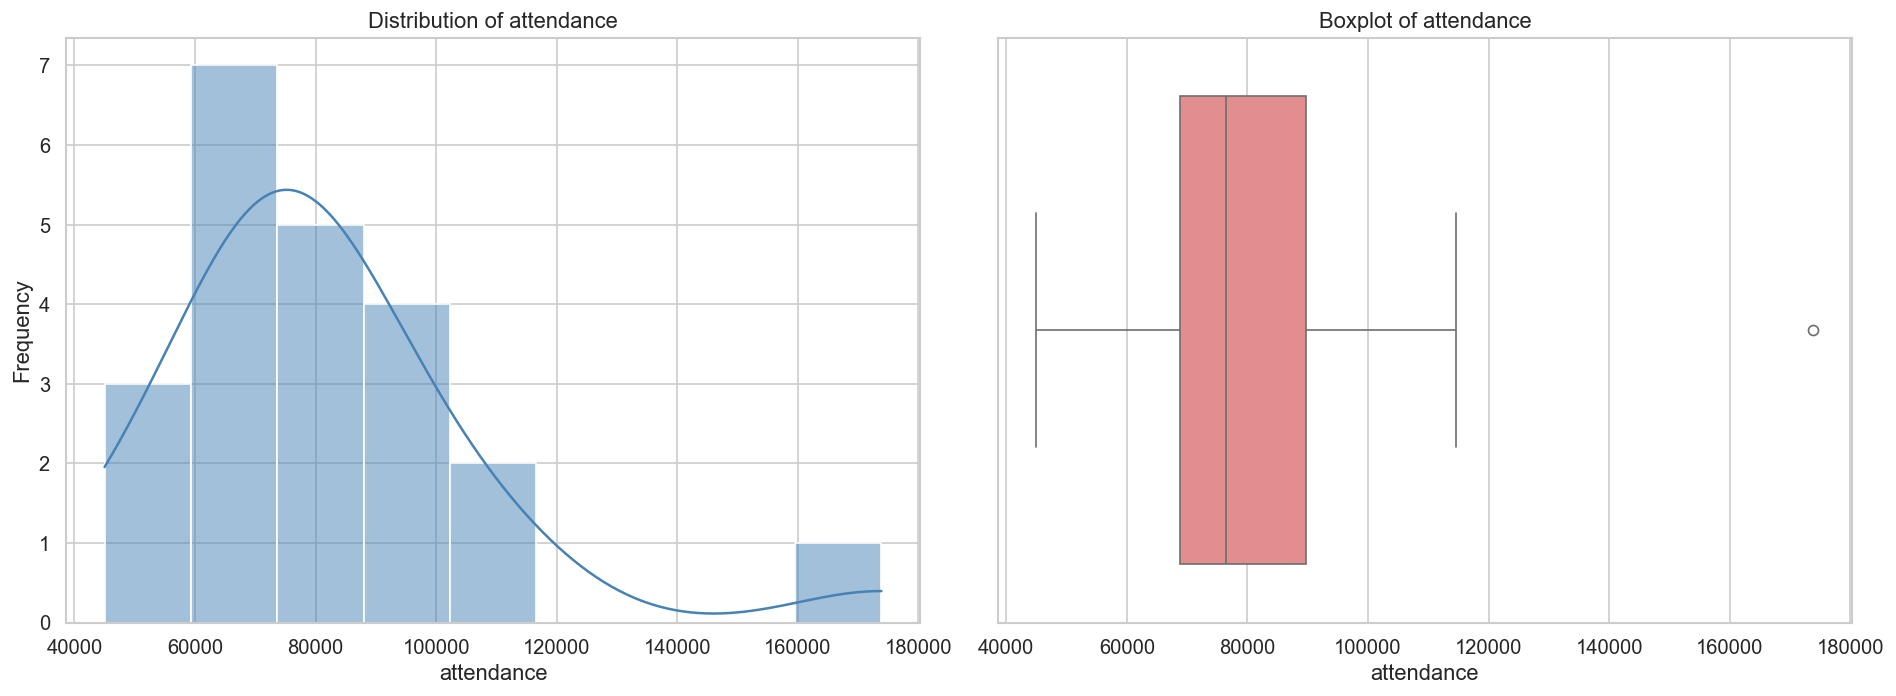

In [35]:
plot_distribution(df, "attendance")

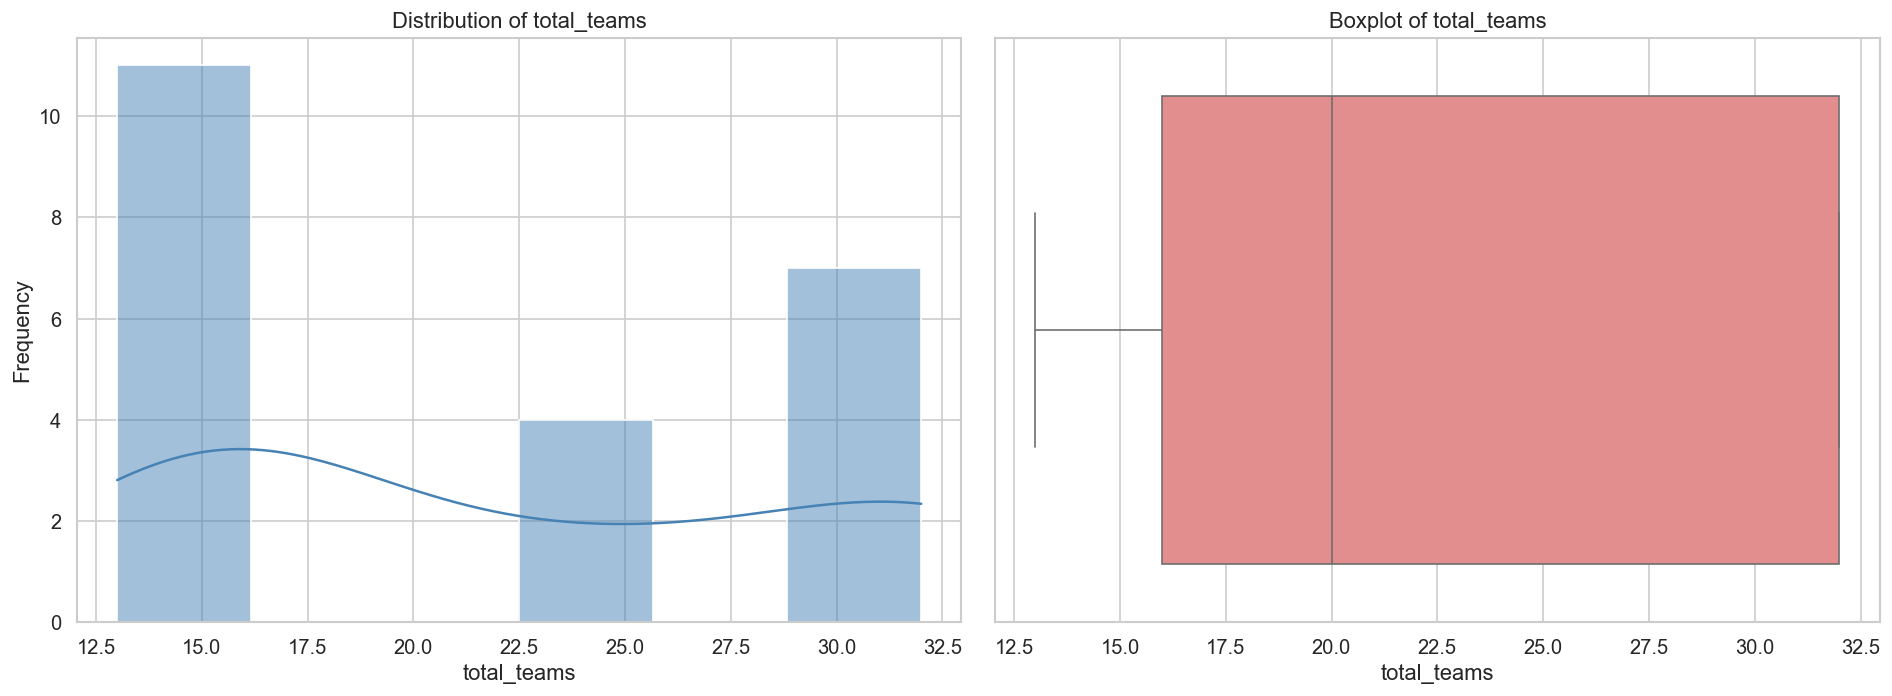

In [36]:
plot_distribution(df, "total_teams")

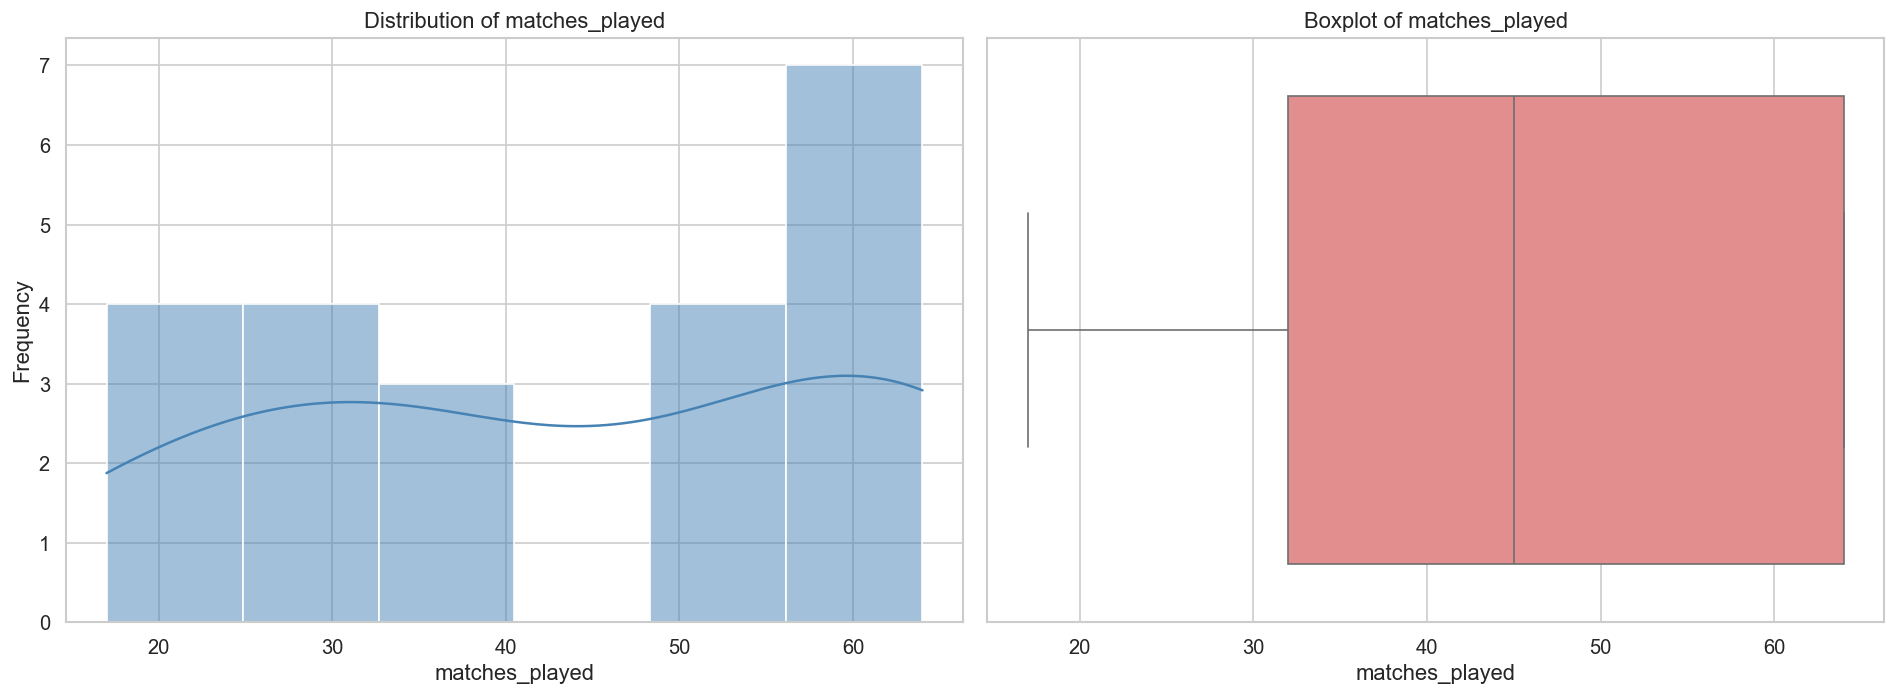

In [37]:
plot_distribution(df, "matches_played")

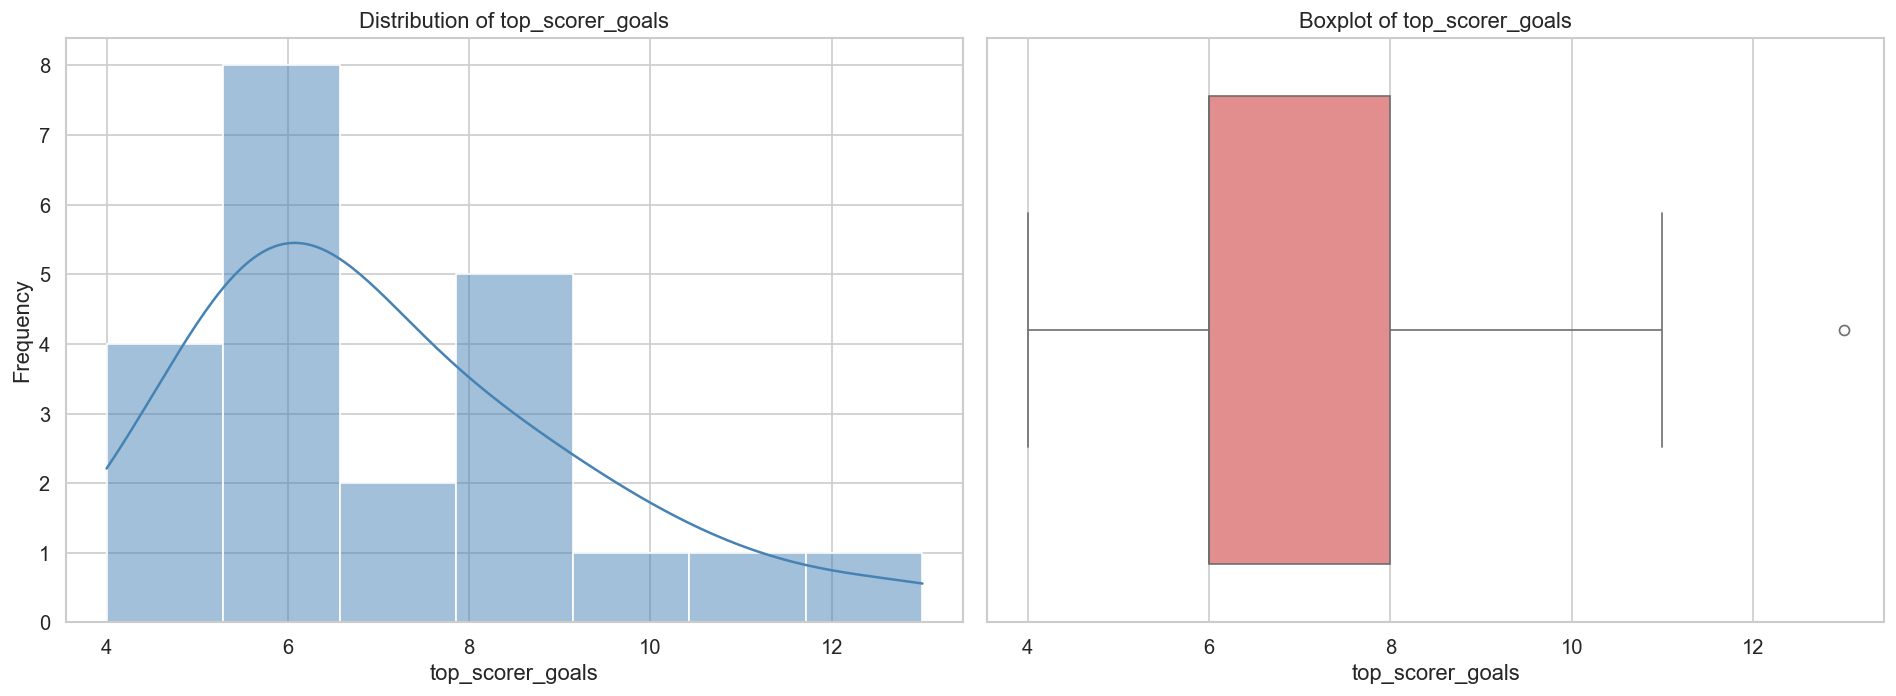

In [38]:
plot_distribution(df, "top_scorer_goals")

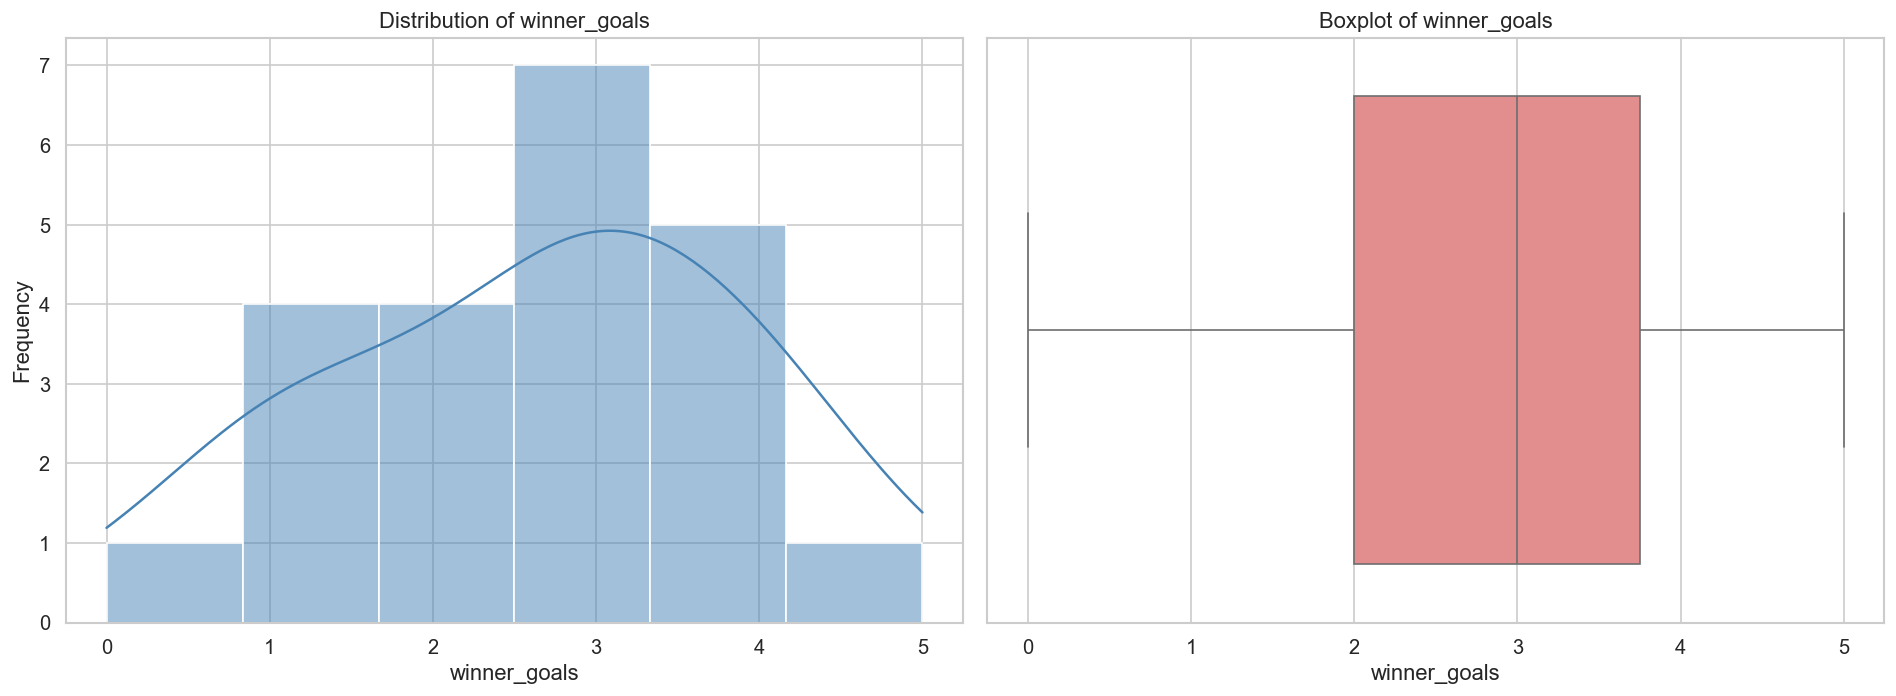

In [39]:
plot_distribution(df, "winner_goals")

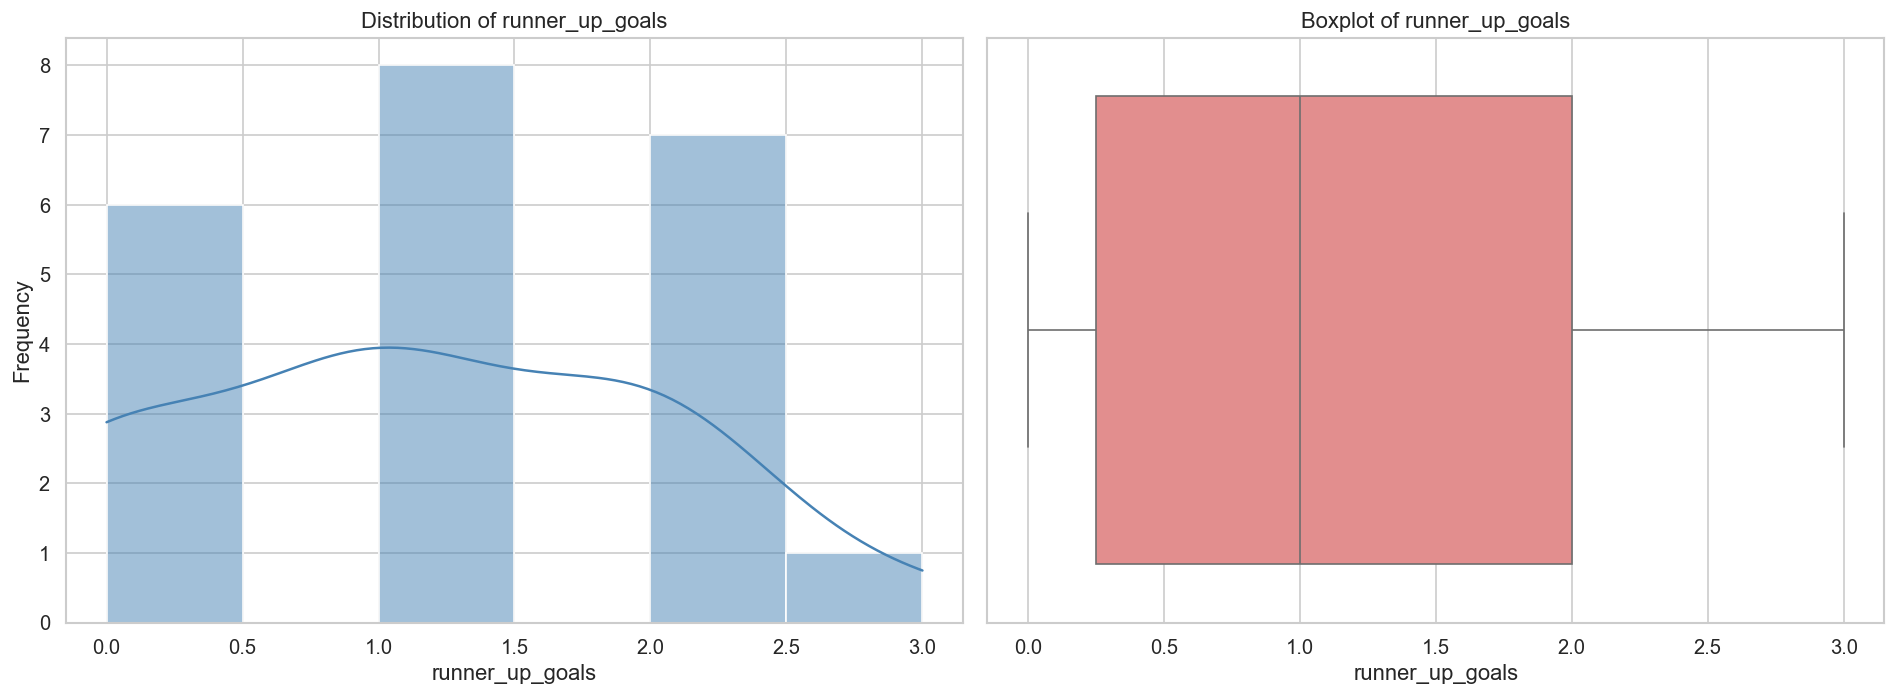

In [40]:
plot_distribution(df, "runner_up_goals")

In [41]:
# ===========================================
# Correlation matrix
# ===========================================

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,year,winner_goals,runner_up_goals,attendance,total_teams,matches_played,winner_titles_after_win,top_scorer_goals
year,1.000000,-0.415314,-0.291116,0.086831,0.913915,0.970050,0.523261,-0.331581
winner_goals,-0.415314,1.000000,0.708325,-0.157719,-0.422419,-0.418780,-0.513836,0.540139
runner_up_goals,-0.291116,0.708325,1.000000,-0.055124,-0.328948,-0.359902,-0.377596,0.430600
attendance,0.086831,-0.157719,-0.055124,1.000000,-0.059504,0.018760,0.096213,0.076465
total_teams,0.913915,-0.422419,-0.328948,-0.059504,1.000000,0.955832,0.507779,-0.399738
matches_played,0.970050,-0.418780,-0.359902,0.018760,0.955832,1.000000,0.523784,-0.359633
winner_titles_after_win,0.523261,-0.513836,-0.377596,0.096213,0.507779,0.523784,1.000000,-0.188677
top_scorer_goals,-0.331581,0.540139,0.430600,0.076465,-0.399738,-0.359633,-0.188677,1.000000


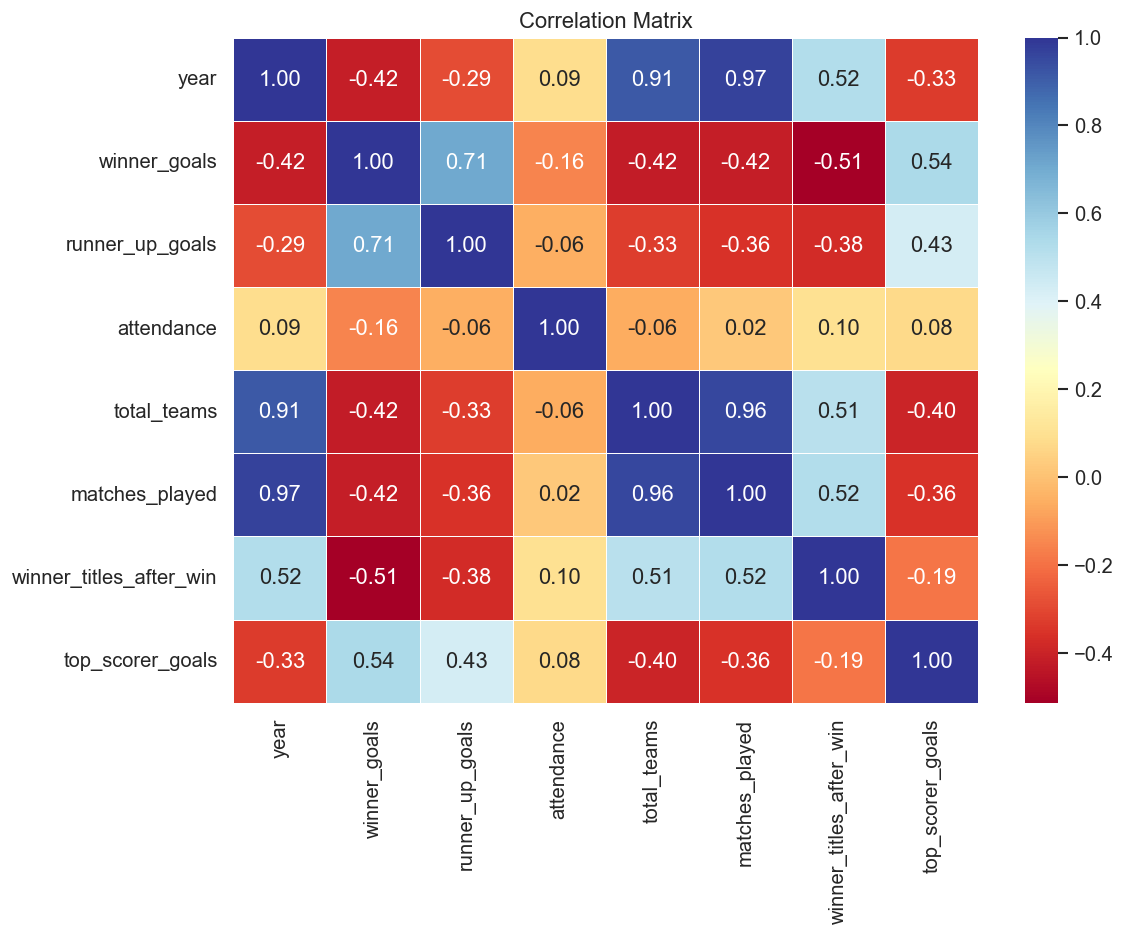

In [42]:
# ===========================================
# Correlation heatmap
# ===========================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdYlBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

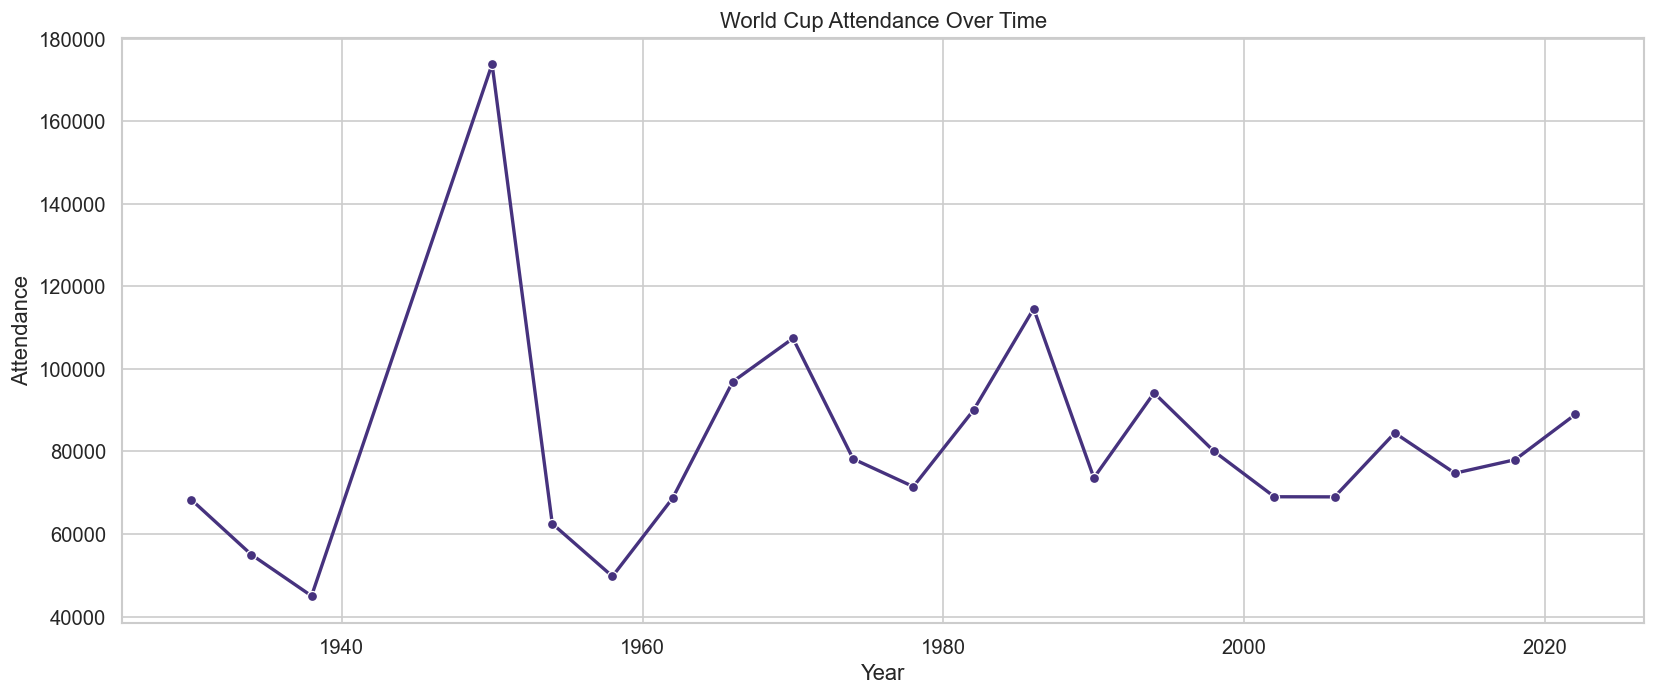

In [43]:
# ===========================================
# Attendance over time
# ===========================================

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="year",
    y="attendance",
    marker="o",
    linewidth=2
)

plt.title("World Cup Attendance Over Time")

plt.xlabel("Year")

plt.ylabel("Attendance")

plt.tight_layout()

plt.show()

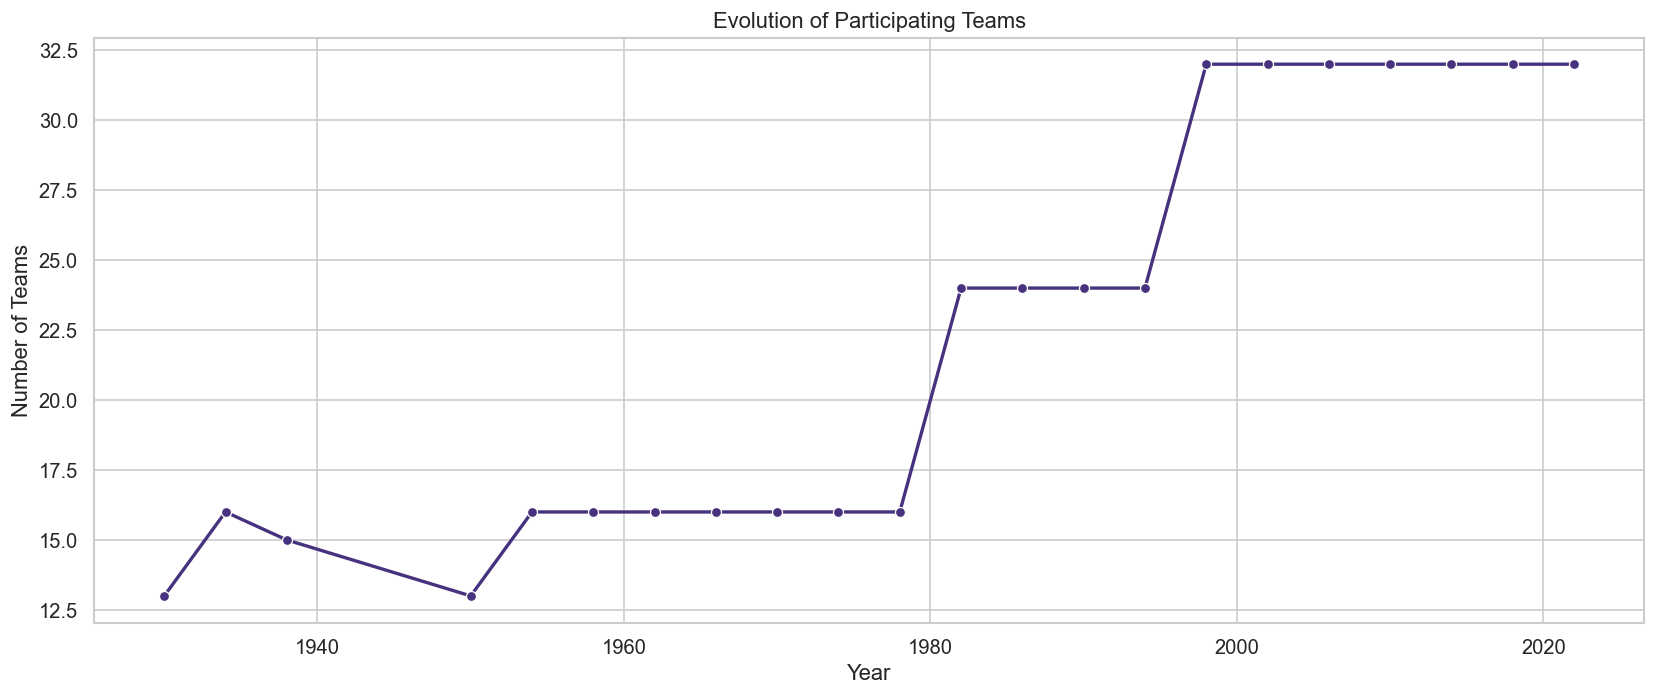

In [44]:
# ===========================================
# Participating teams over time
# ===========================================

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="year",
    y="total_teams",
    marker="o",
    linewidth=2
)

plt.title("Evolution of Participating Teams")

plt.xlabel("Year")

plt.ylabel("Number of Teams")

plt.tight_layout()

plt.show()

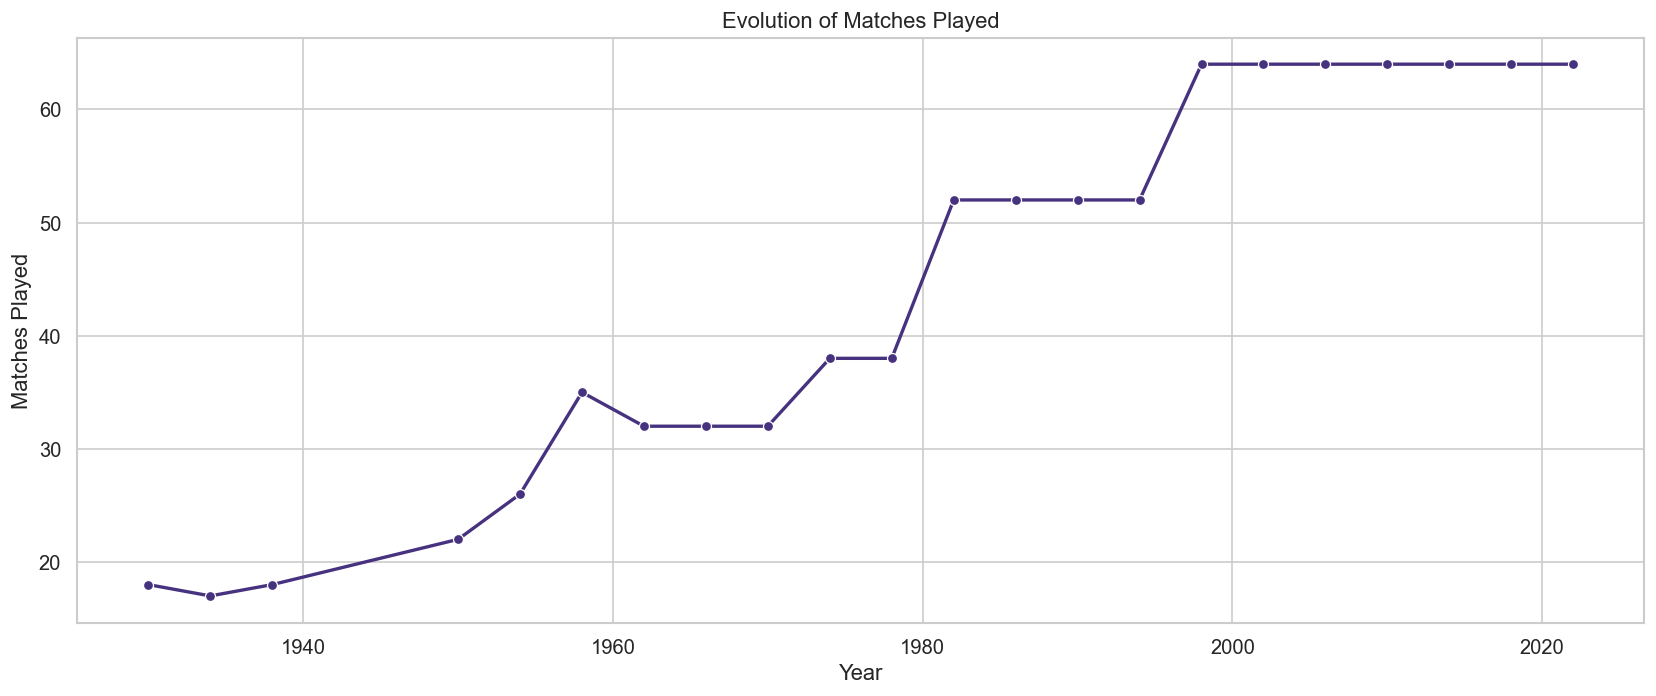

In [45]:
# ===========================================
# Matches played over time
# ===========================================

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="year",
    y="matches_played",
    marker="o",
    linewidth=2
)

plt.title("Evolution of Matches Played")

plt.xlabel("Year")

plt.ylabel("Matches Played")

plt.tight_layout()

plt.show()

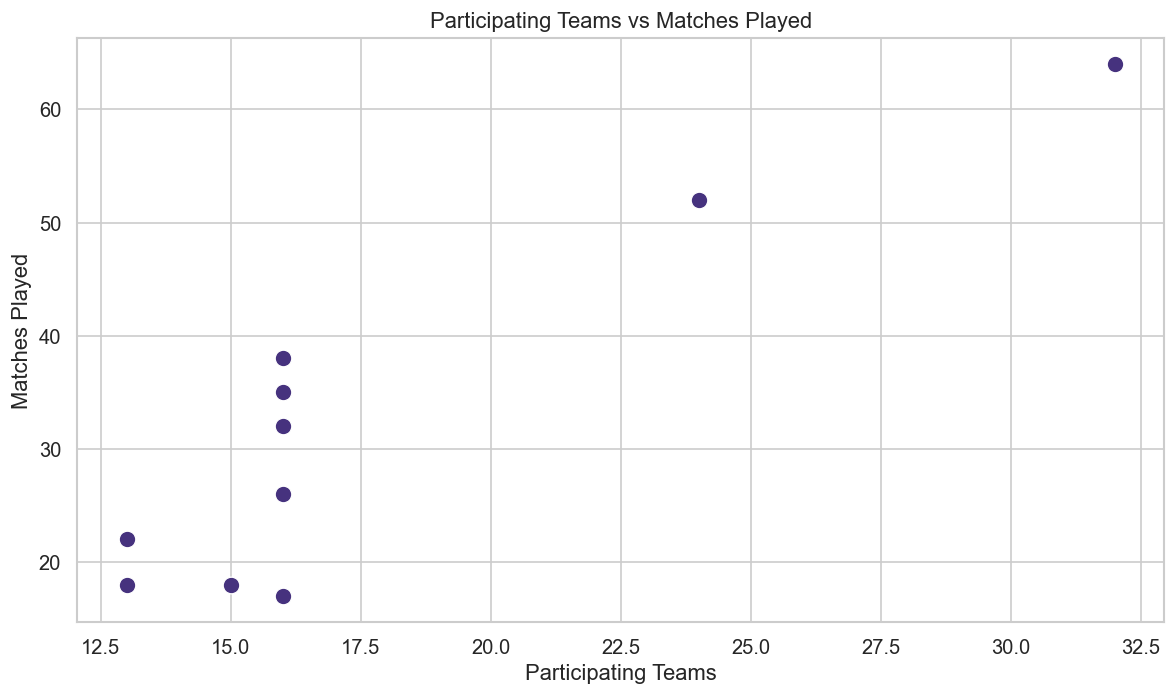

In [46]:
# ===========================================
# Teams vs matches
# ===========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="total_teams",
    y="matches_played",
    s=100
)

plt.title("Participating Teams vs Matches Played")

plt.xlabel("Participating Teams")

plt.ylabel("Matches Played")

plt.tight_layout()

plt.show()

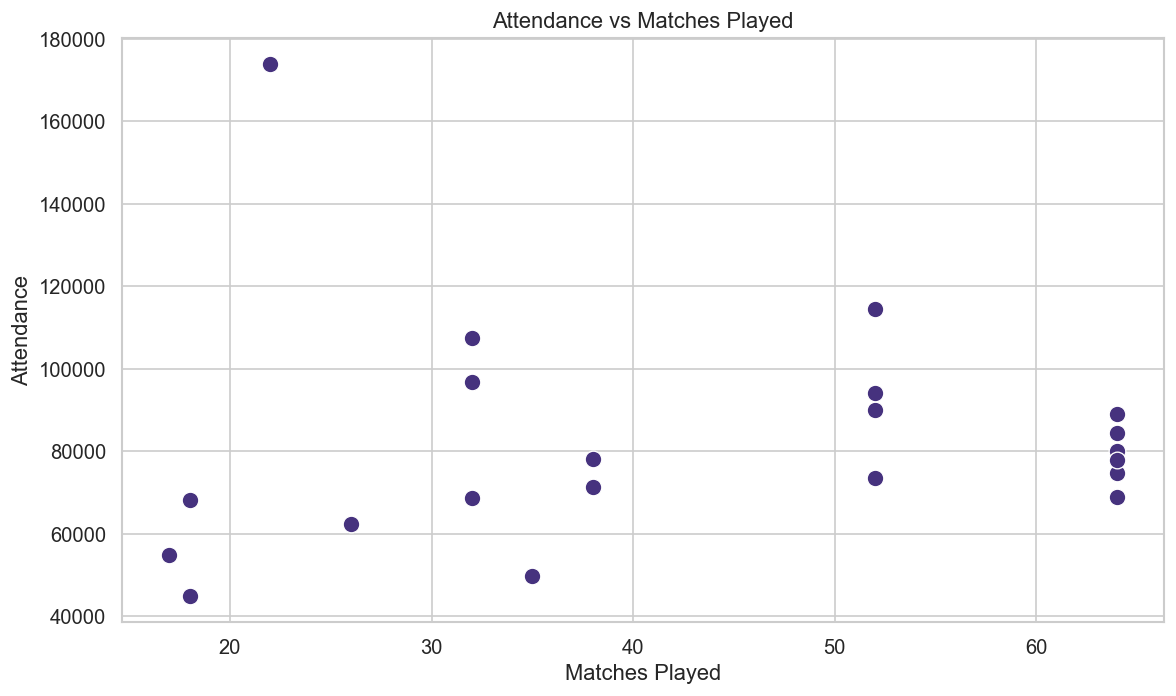

In [47]:
# ===========================================
# Attendance vs matches
# ===========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="matches_played",
    y="attendance",
    s=100
)

plt.title("Attendance vs Matches Played")

plt.xlabel("Matches Played")

plt.ylabel("Attendance")

plt.tight_layout()

plt.show()

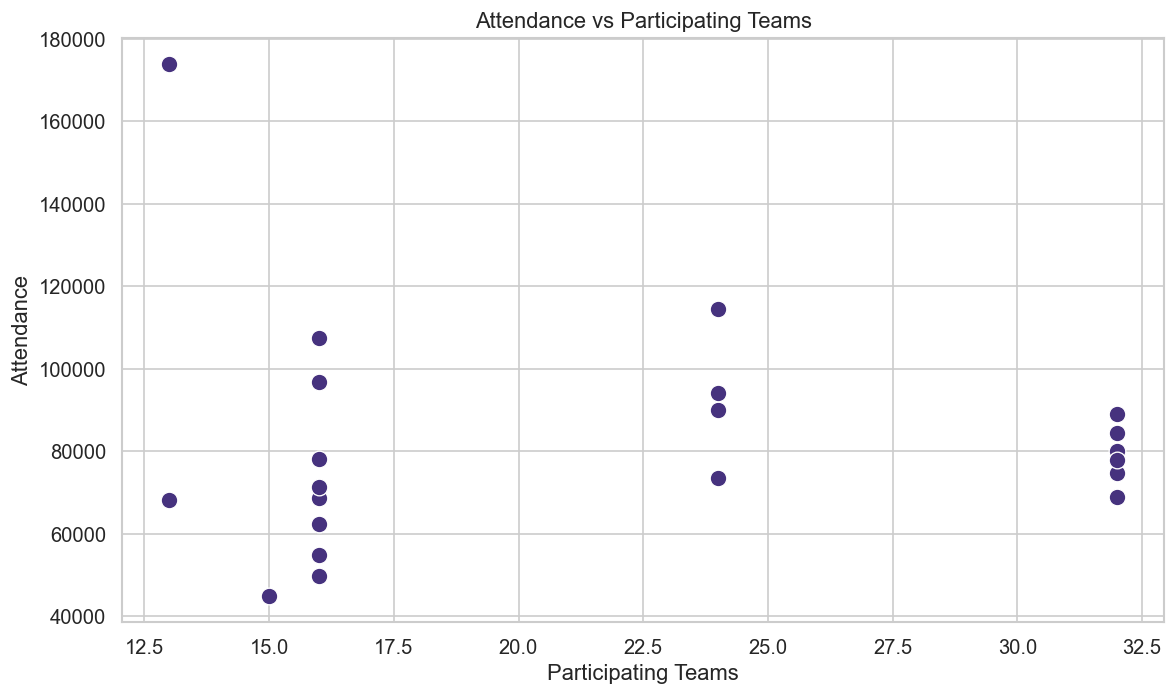

In [48]:
# ===========================================
# Attendance vs participating teams
# ===========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="total_teams",
    y="attendance",
    s=100
)

plt.title("Attendance vs Participating Teams")

plt.xlabel("Participating Teams")

plt.ylabel("Attendance")

plt.tight_layout()

plt.show()

In [49]:
# ===========================================
# Categorical variables
# ===========================================

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical variables:\n")

for column in categorical_columns:
    print(f"- {column}")

Categorical variables:

- host_country
- host_city_final
- stadium
- winner
- runner_up
- winner_captain
- winner_head_coach
- win_method
- continent_winner
- golden_ball
- golden_boot
- best_young_player
- golden_glove
- mascot
- official_ball


In [50]:
# ===========================================
# World Cup titles by country
# ===========================================

champion_frequency = (
    df["winner"]
    .value_counts()
)

champion_frequency

winner
Brazil          5
Italy           4
West Germany    3
Argentina       3
Uruguay         2
France          2
England         1
Spain           1
Germany         1
Name: count, dtype: int64

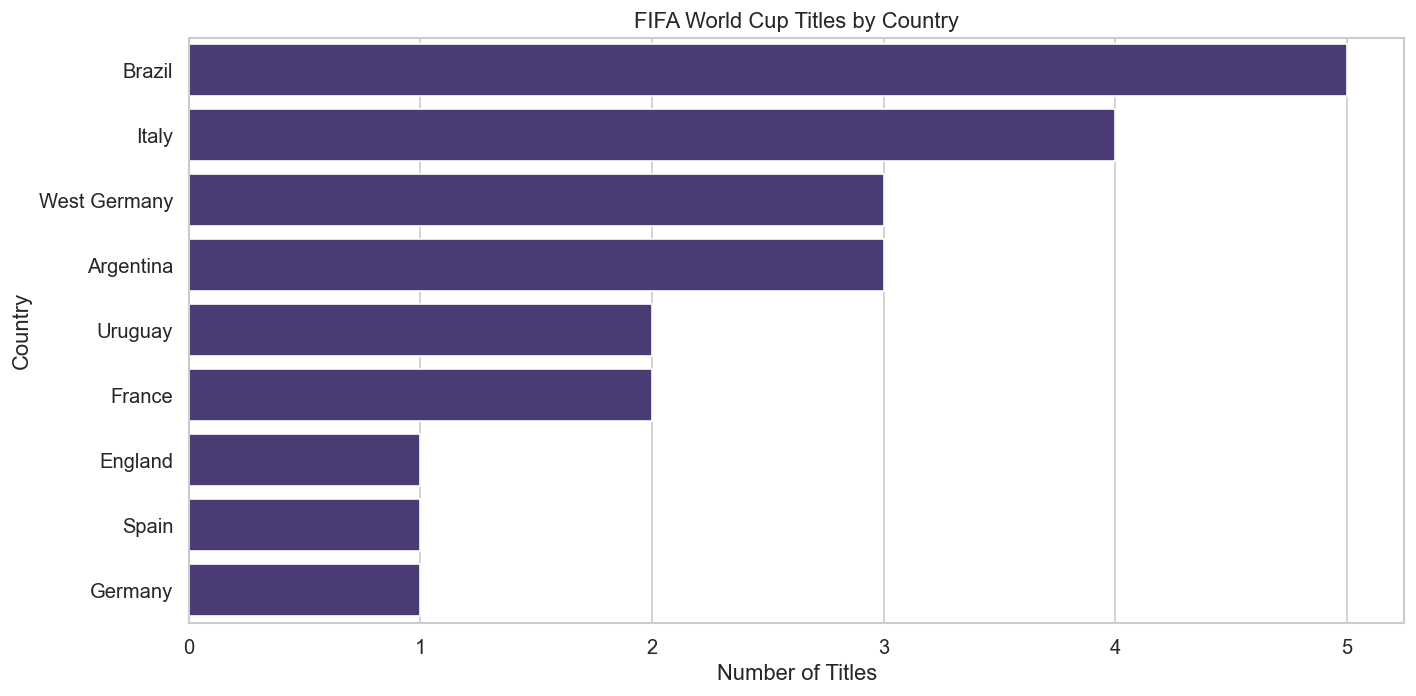

In [51]:
# ===========================================
# World Cup titles by country
# ===========================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=champion_frequency.values,
    y=champion_frequency.index
)

plt.title("FIFA World Cup Titles by Country")

plt.xlabel("Number of Titles")

plt.ylabel("Country")

plt.tight_layout()

plt.show()

In [52]:
# ===========================================
# Host countries
# ===========================================

host_frequency = (
    df["host_country"]
      .value_counts()
)

host_frequency

host_country
Italy                2
France               2
Brazil               2
Mexico               2
Uruguay              1
Switzerland          1
Sweden               1
Chile                1
England              1
West Germany         1
Argentina            1
Spain                1
United States        1
South Korea/Japan    1
Germany              1
South Africa         1
Russia               1
Qatar                1
Name: count, dtype: int64

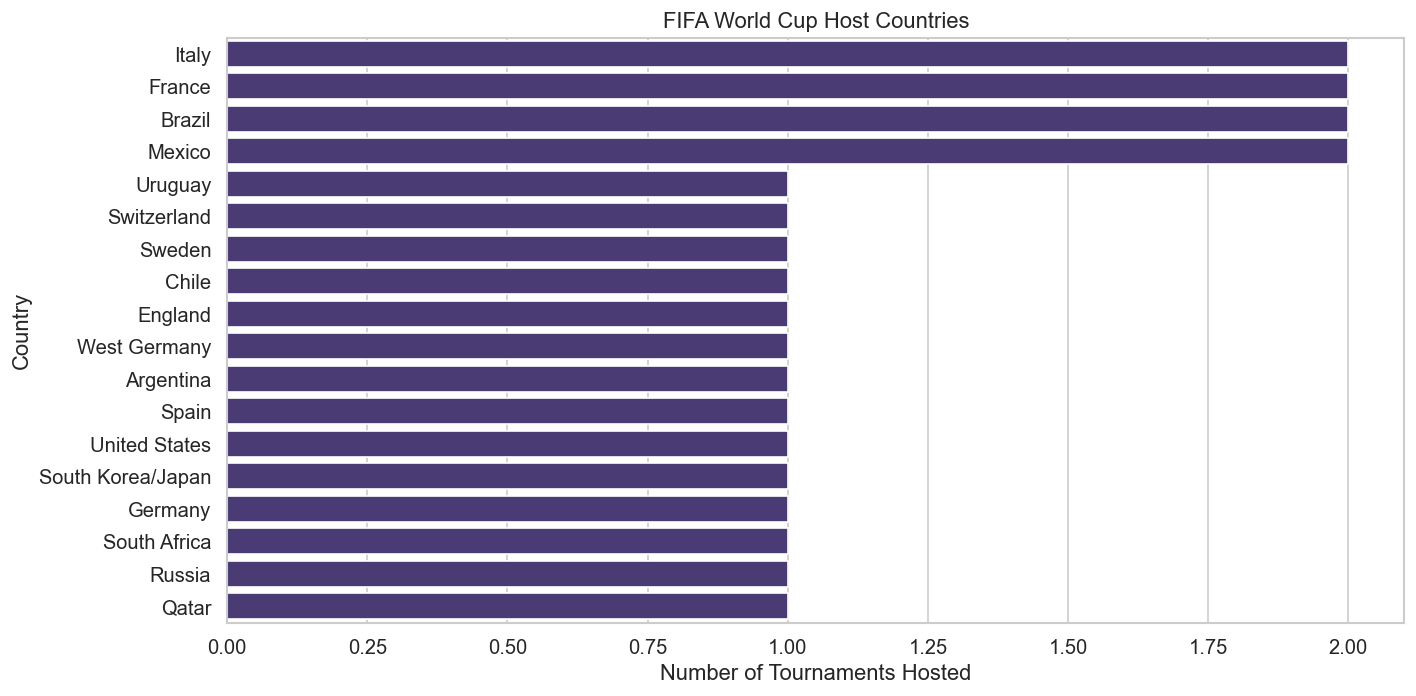

In [53]:
# ===========================================
# Host countries bar chart
# ===========================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=host_frequency.values,
    y=host_frequency.index
)

plt.title("FIFA World Cup Host Countries")

plt.xlabel("Number of Tournaments Hosted")

plt.ylabel("Country")

plt.tight_layout()

plt.show()

In [54]:
# ===========================================
# Winning continents
# ===========================================

continent_frequency = (
    df["continent_winner"]
      .value_counts()
)

continent_frequency

continent_winner
Europe           12
South America    10
Name: count, dtype: int64

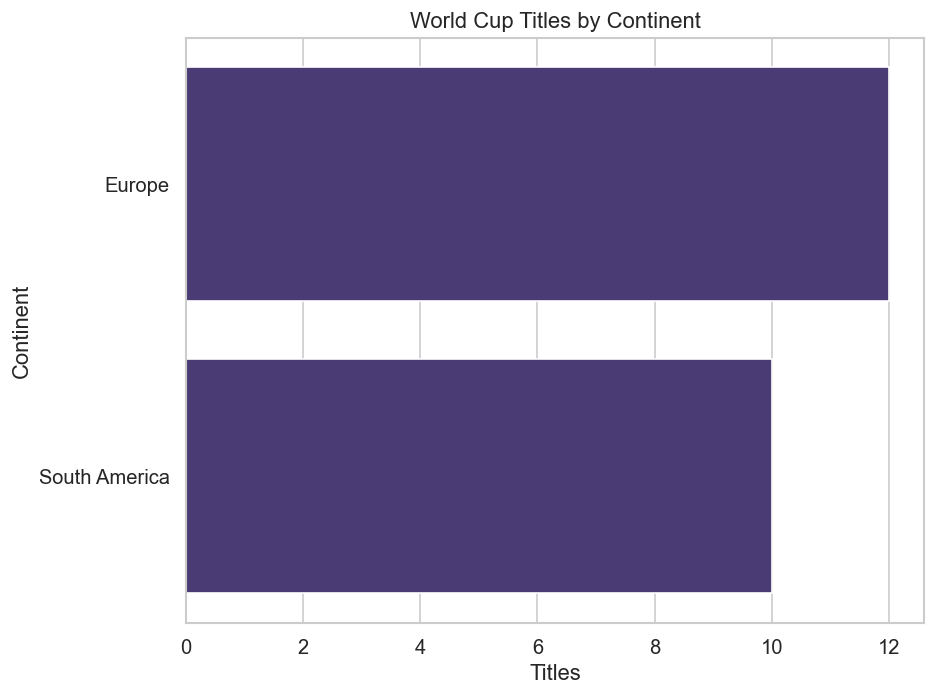

In [55]:
# ===========================================
# Winning continents
# ===========================================

plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    y="continent_winner",
    order=continent_frequency.index
)

plt.title("World Cup Titles by Continent")

plt.xlabel("Titles")

plt.ylabel("Continent")

plt.tight_layout()

plt.show()

In [56]:
# ===========================================
# Runner-up countries
# ===========================================

runner_up_frequency = (
    df["runner_up"]
      .value_counts()
)

runner_up_frequency

runner_up
Argentina         3
West Germany      3
Netherlands       3
Czechoslovakia    2
Hungary           2
Brazil            2
Italy             2
France            2
Sweden            1
Germany           1
Croatia           1
Name: count, dtype: int64

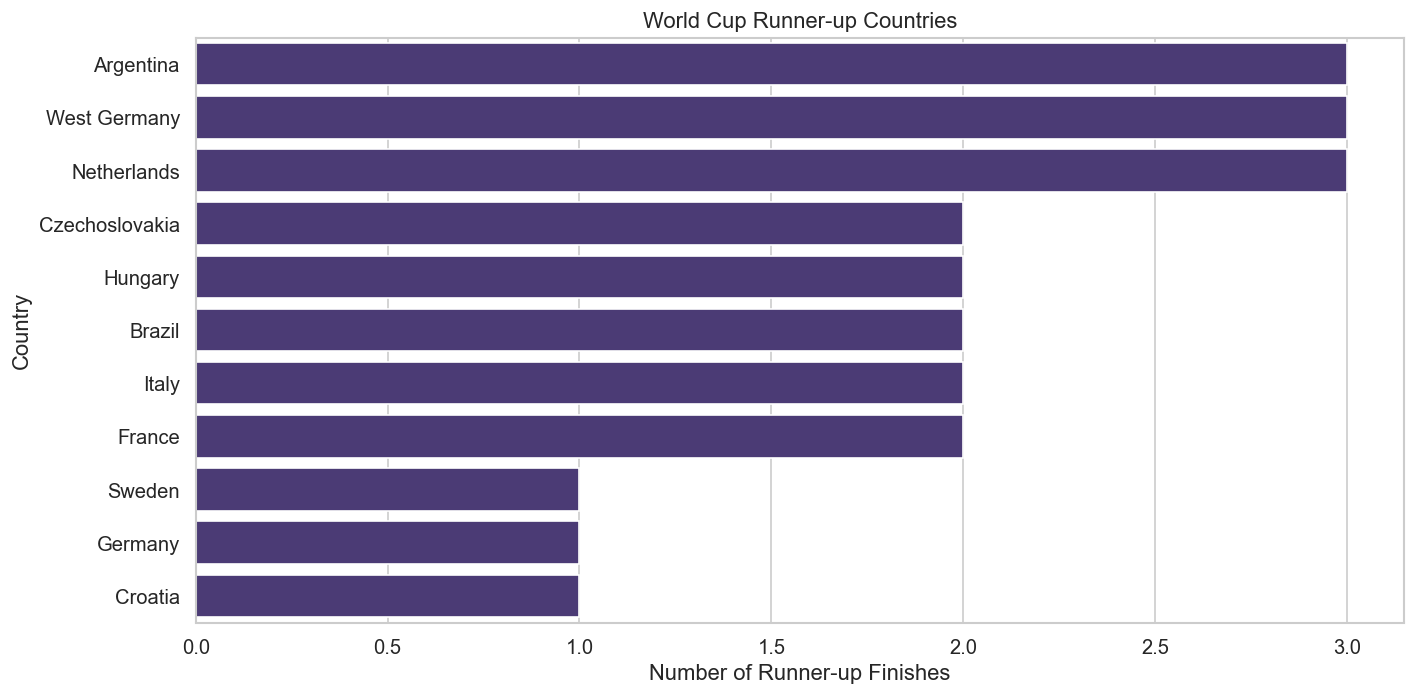

In [57]:
# ===========================================
# Runner-up countries
# ===========================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=runner_up_frequency.values,
    y=runner_up_frequency.index
)

plt.title("World Cup Runner-up Countries")

plt.xlabel("Number of Runner-up Finishes")

plt.ylabel("Country")

plt.tight_layout()

plt.show()

In [58]:
# ===========================================
# Winning head coaches
# ===========================================

coach_frequency = (
    df["winner_head_coach"]
      .value_counts()
)

coach_frequency

winner_head_coach
Vittorio Pozzo             2
Alberto Suppici            1
Juan López Fontana         1
Sepp Herberger             1
Vicente Feola              1
Aymoré Moreira             1
Alf Ramsey                 1
Mário Zagallo              1
Helmut Schön               1
César Luis Menotti         1
Enzo Bearzot               1
Carlos Bilardo             1
Franz Beckenbauer          1
Carlos Alberto Parreira    1
Aimé Jacquet               1
Luiz Felipe Scolari        1
Marcello Lippi             1
Vicente del Bosque         1
Joachim Löw                1
Didier Deschamps           1
Lionel Scaloni             1
Name: count, dtype: int64

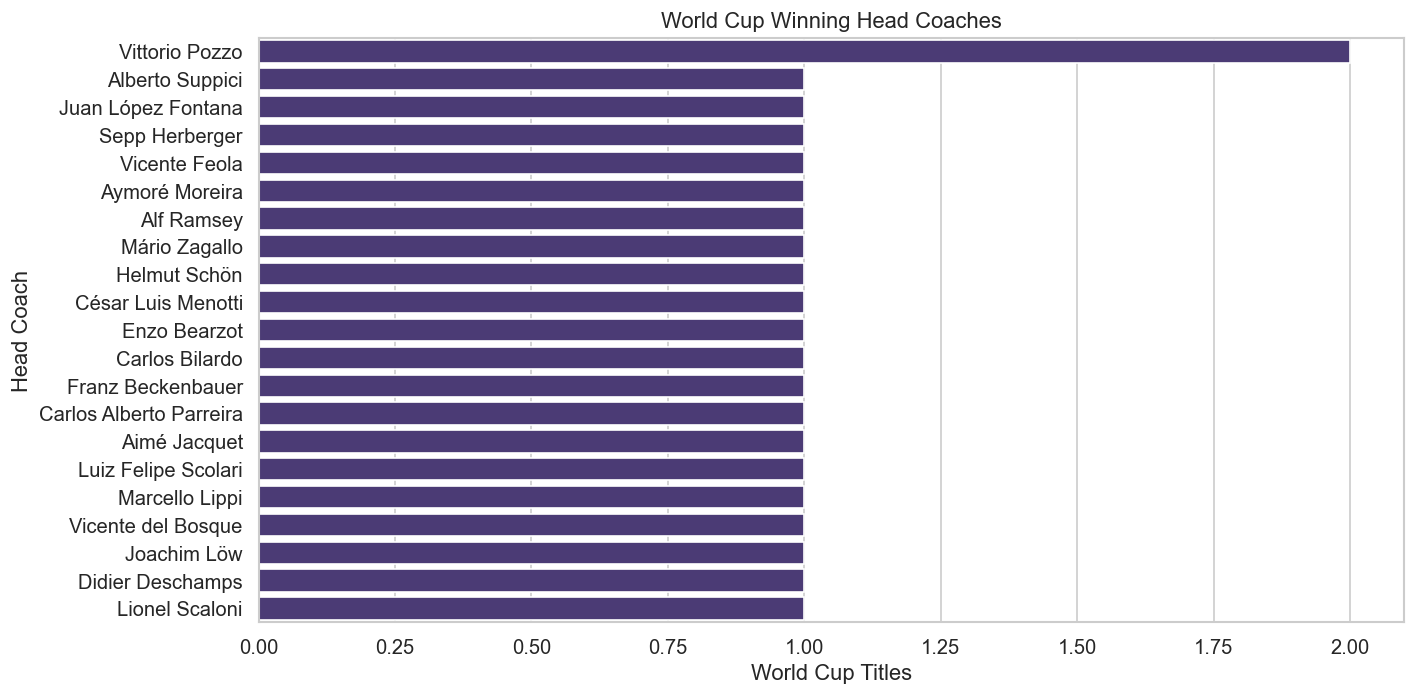

In [59]:
# ===========================================
# Winning head coaches
# ===========================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=coach_frequency.values,
    y=coach_frequency.index
)

plt.title("World Cup Winning Head Coaches")

plt.xlabel("World Cup Titles")

plt.ylabel("Head Coach")

plt.tight_layout()

plt.show()

In [60]:
# ===========================================
# Winning captains
# ===========================================

captain_frequency = (
    df["winner_captain"]
      .value_counts()
)

captain_frequency

winner_captain
José Nasazzi             1
Gianpiero Combi          1
Giuseppe Meazza          1
Obdulio Varela           1
Fritz Walter             1
Hilderaldo Bellini       1
Mauro                    1
Bobby Moore              1
Carlos Alberto Torres    1
Franz Beckenbauer        1
Daniel Passarella        1
Dino Zoff                1
Diego Maradona           1
Lothar Matthäus          1
Dunga                    1
Didier Deschamps         1
Cafu                     1
Fabio Cannavaro          1
Iker Casillas            1
Philipp Lahm             1
Hugo Lloris              1
Lionel Messi             1
Name: count, dtype: int64

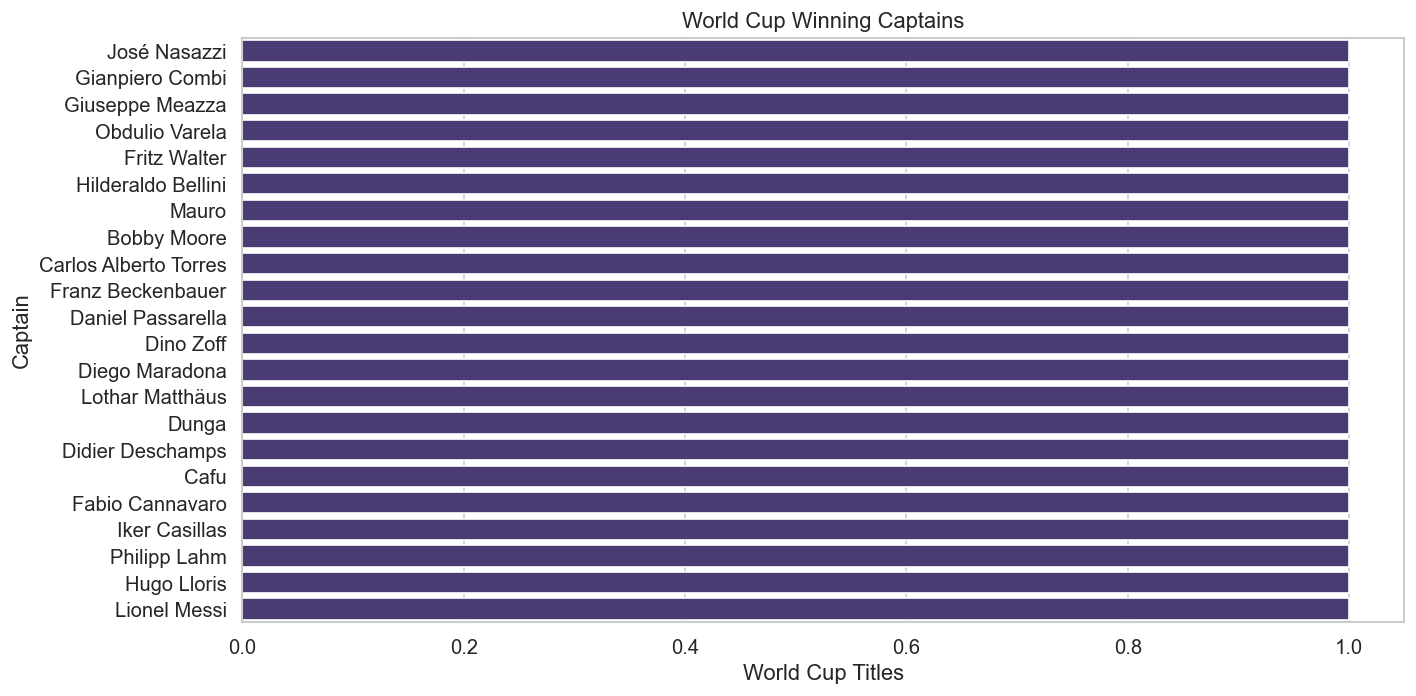

In [61]:
# ===========================================
# Winning captains
# ===========================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=captain_frequency.values,
    y=captain_frequency.index
)

plt.title("World Cup Winning Captains")

plt.xlabel("World Cup Titles")

plt.ylabel("Captain")

plt.tight_layout()

plt.show()

# Historical Insight 1

## How Has the Champion Continent Changed Over Time?

One of the most interesting historical questions is whether the dominance of World Cup champions has shifted between continents over time.

This analysis illustrates the winning continent for each tournament edition, allowing us to identify periods of continental dominance and historical transitions.

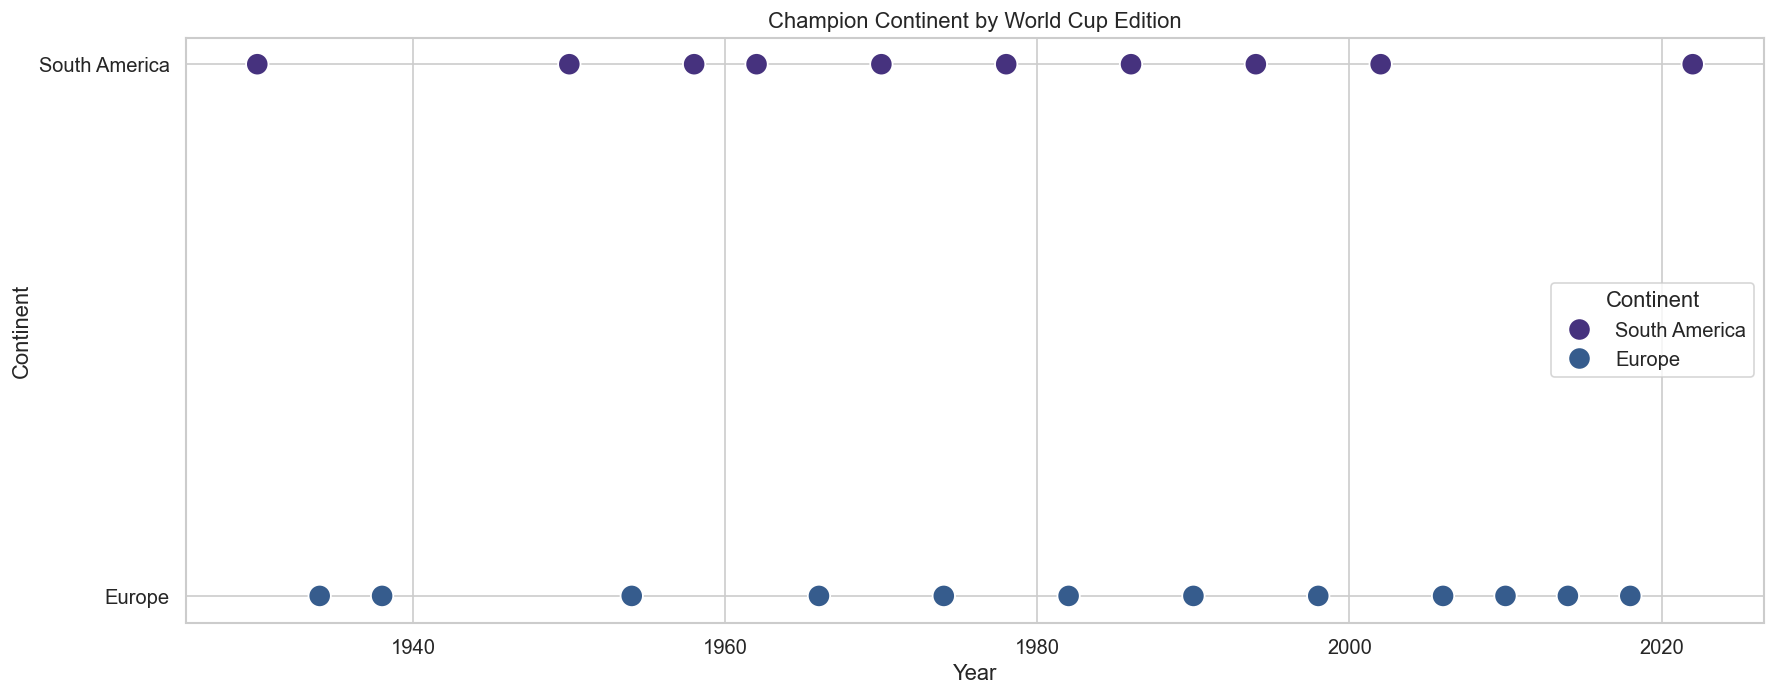

In [62]:
# ===========================================
# Champion continent over time
# ===========================================

plt.figure(figsize=(15, 6))

sns.scatterplot(
    data=df,
    x="year",
    y="continent_winner",
    hue="continent_winner",
    s=180
)

plt.title("Champion Continent by World Cup Edition")

plt.xlabel("Year")

plt.ylabel("Continent")

plt.legend(title="Continent")

plt.tight_layout()

plt.show()

# Historical Insight 2

## Which Countries Won Consecutive World Cup Titles?

Winning a FIFA World Cup is already an extraordinary achievement.

Winning consecutive editions is even more remarkable and reflects periods of sustained dominance.

In [63]:
# ===========================================
# Consecutive champions
# ===========================================

consecutive_titles = []

for i in range(1, len(df)):

    if df.loc[i, "winner"] == df.loc[i - 1, "winner"]:

        consecutive_titles.append({
            "Country": df.loc[i, "winner"],
            "Years": f"{df.loc[i - 1, 'year']} - {df.loc[i, 'year']}"
        })

consecutive_titles = pd.DataFrame(consecutive_titles)

consecutive_titles

,Country,Years
0,Italy,1934 - 1938
1,Brazil,1958 - 1962


# Historical Insight 3

## How Has the Winning Margin Changed Over Time?

The goal difference in the final match provides an interesting perspective on the competitiveness of FIFA World Cup finals.

Lower margins generally indicate more balanced matches, while larger margins may reflect dominant performances.

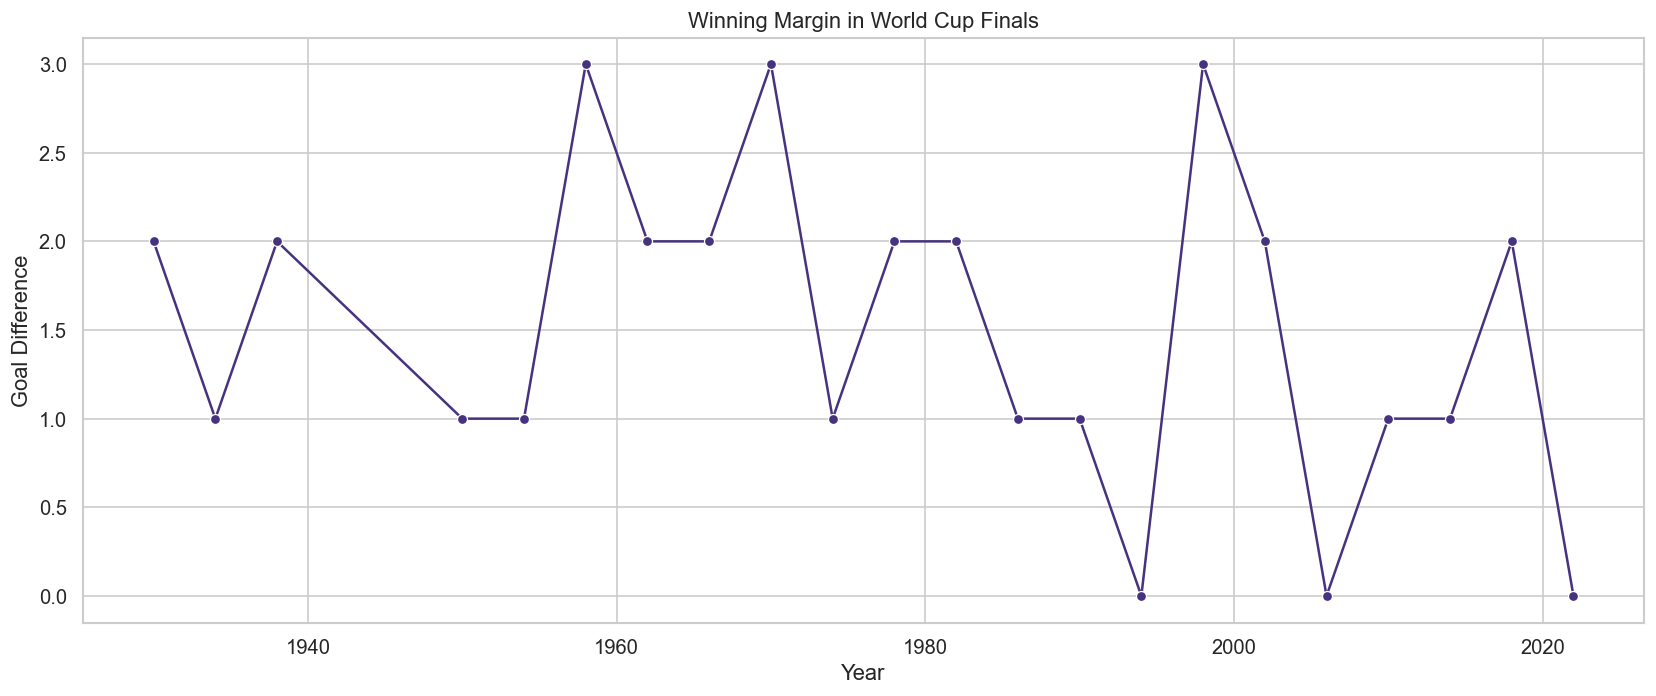

In [64]:
# ===========================================
# Winning margin
# ===========================================

df["winning_margin"] = (
    df["winner_goals"]
    - df["runner_up_goals"]
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x="year",
    y="winning_margin",
    marker="o"
)

plt.title("Winning Margin in World Cup Finals")

plt.xlabel("Year")

plt.ylabel("Goal Difference")

plt.tight_layout()

plt.show()

# Historical Insight 4

## How Were World Cup Finals Decided?

Not every FIFA World Cup final is decided within regular time.

This analysis compares the different methods by which champions secured the title.

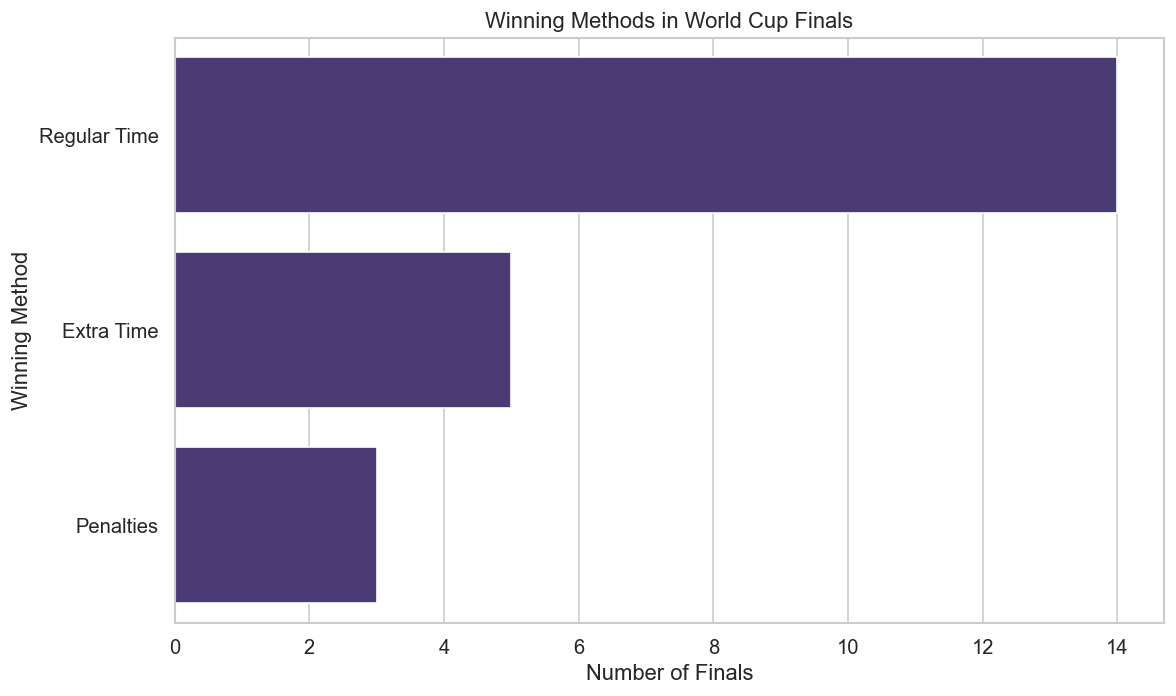

In [65]:
# ===========================================
# Winning methods
# ===========================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="win_method",
    order=df["win_method"].value_counts().index
)

plt.title("Winning Methods in World Cup Finals")

plt.xlabel("Number of Finals")

plt.ylabel("Winning Method")

plt.tight_layout()

plt.show()

# Historical Insight 5

## Evolution of Accumulated World Cup Titles

Each FIFA World Cup victory contributes to the historical legacy of the champion nation.

This analysis illustrates how the total number of titles accumulated by the winning country evolved over time.

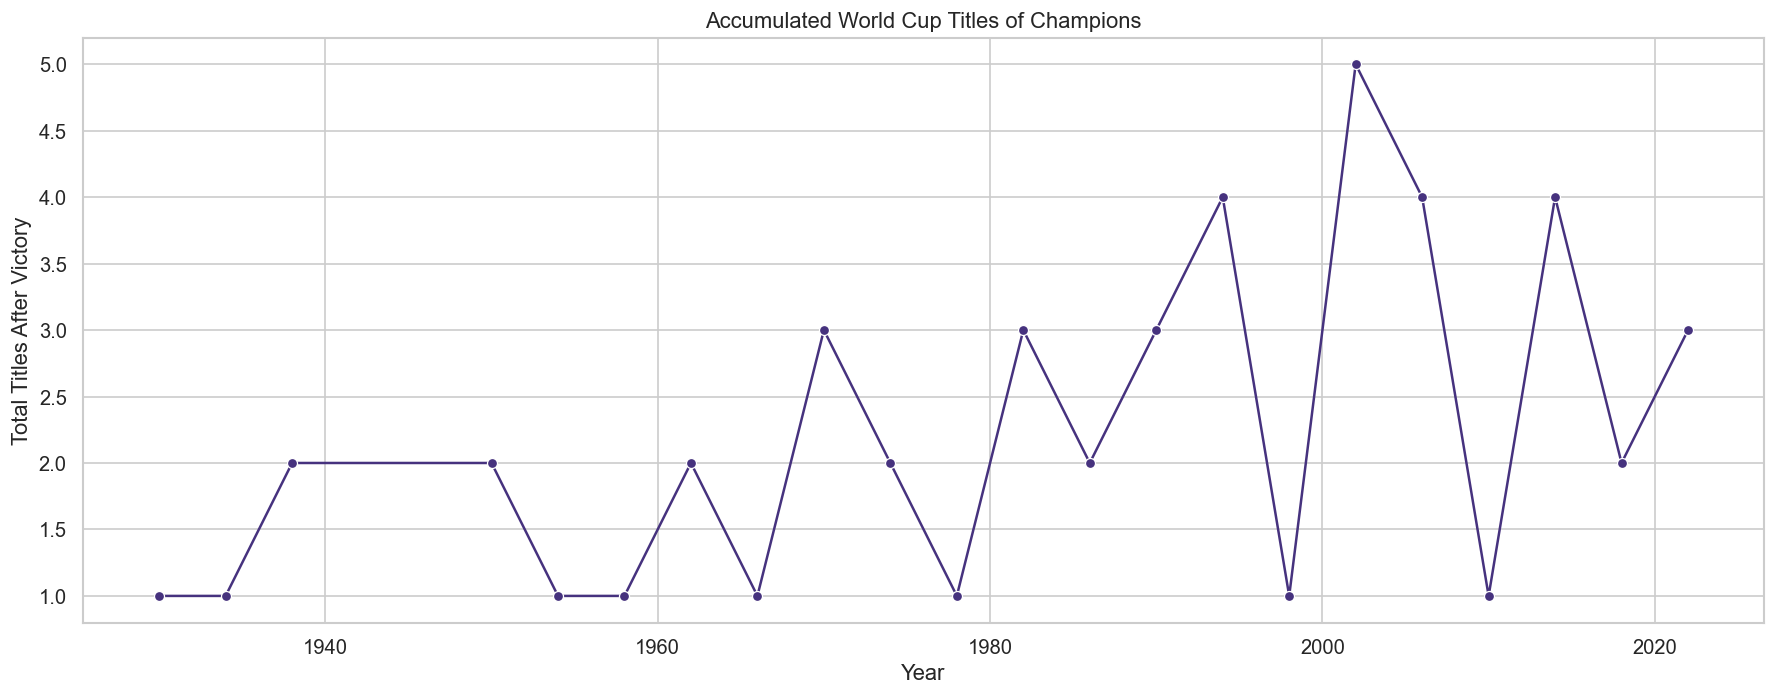

In [66]:
# ===========================================
# Accumulated titles
# ===========================================

plt.figure(figsize=(15,6))

sns.lineplot(
    data=df,
    x="year",
    y="winner_titles_after_win",
    marker="o"
)

plt.title("Accumulated World Cup Titles of Champions")

plt.xlabel("Year")

plt.ylabel("Total Titles After Victory")

plt.tight_layout()

plt.show()

# Historical Insight 6

## Which Host Country Attracted the Largest Attendance?

Hosting a FIFA World Cup is a major event that attracts millions of spectators.

This analysis compares the total tournament attendance across host countries, highlighting which nations welcomed the largest crowds.

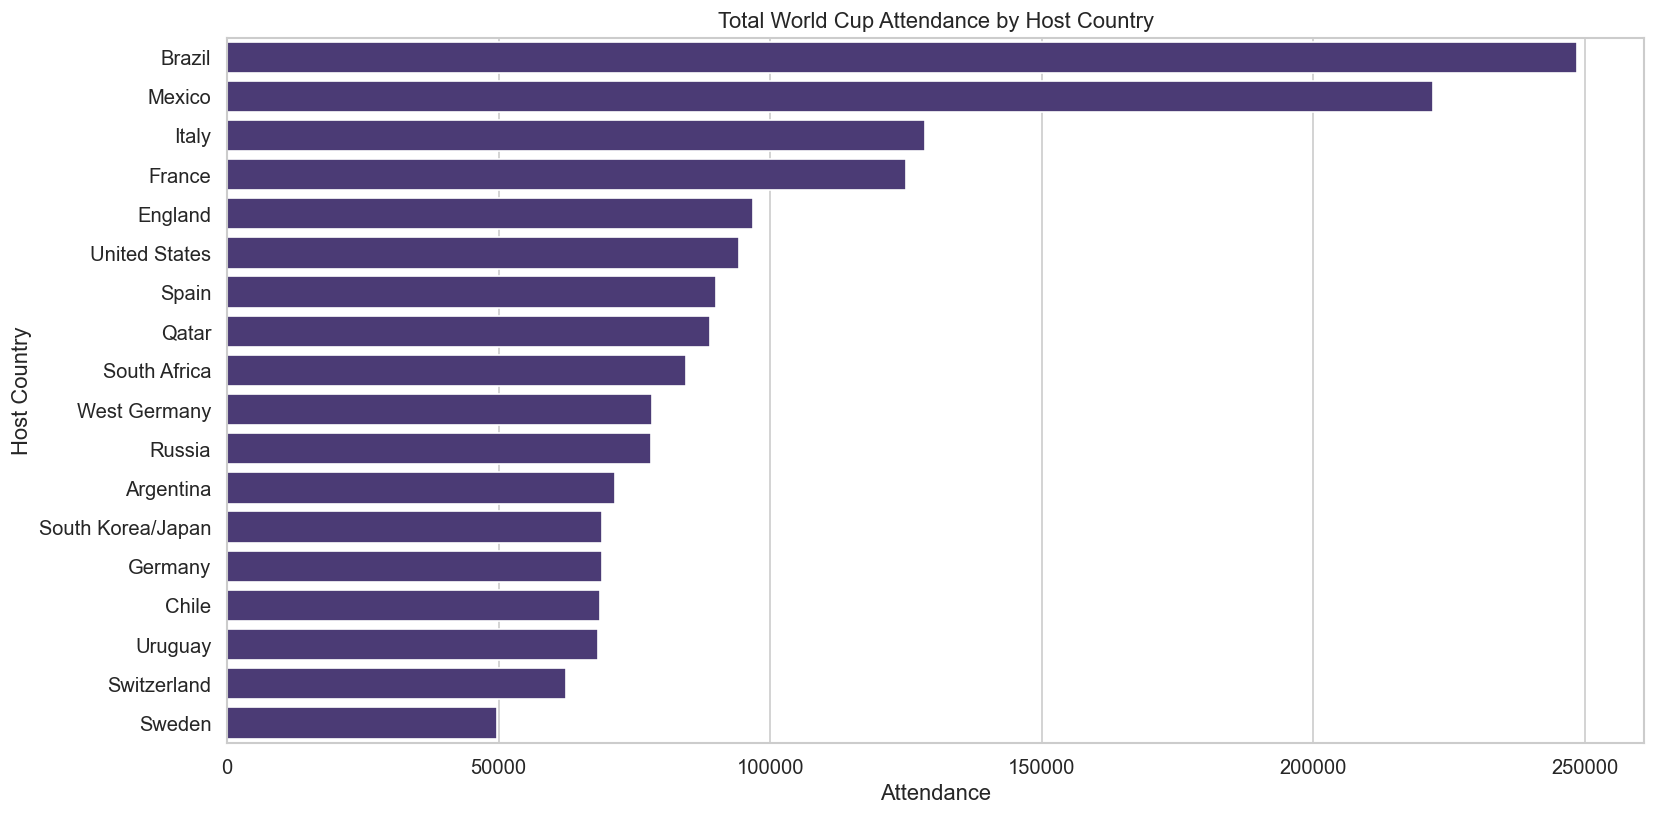

In [67]:
# ===========================================
# Attendance by host country
# ===========================================

attendance_by_host = (
    df.groupby("host_country", as_index=False)["attendance"]
      .sum()
      .sort_values("attendance", ascending=False)
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=attendance_by_host,
    x="attendance",
    y="host_country"
)

plt.title("Total World Cup Attendance by Host Country")

plt.xlabel("Attendance")

plt.ylabel("Host Country")

plt.tight_layout()

plt.show()

# Historical Insight 7

## Which Finals Produced the Highest Combined Score?

Some FIFA World Cup finals have been extremely competitive and high-scoring.

This analysis identifies the finals with the largest total number of goals scored by both teams.

In [68]:
# ===========================================
# Total goals in each final
# ===========================================

df["total_final_goals"] = (
    df["winner_goals"]
    + df["runner_up_goals"]
)

highest_scoring_finals = (
    df[
        [
            "year",
            "winner",
            "runner_up",
            "total_final_goals"
        ]
    ]
    .sort_values(
        "total_final_goals",
        ascending=False
    )
)

highest_scoring_finals

,year,winner,runner_up,total_final_goals
5,1958,Brazil,Sweden,7
0,1930,Uruguay,Argentina,6
2,1938,Italy,Hungary,6
21,2022,Argentina,France,6
20,2018,France,Croatia,6
7,1966,England,West Germany,6
12,1986,Argentina,West Germany,5
8,1970,Brazil,Italy,5
4,1954,West Germany,Hungary,5
10,1978,Argentina,Netherlands,4


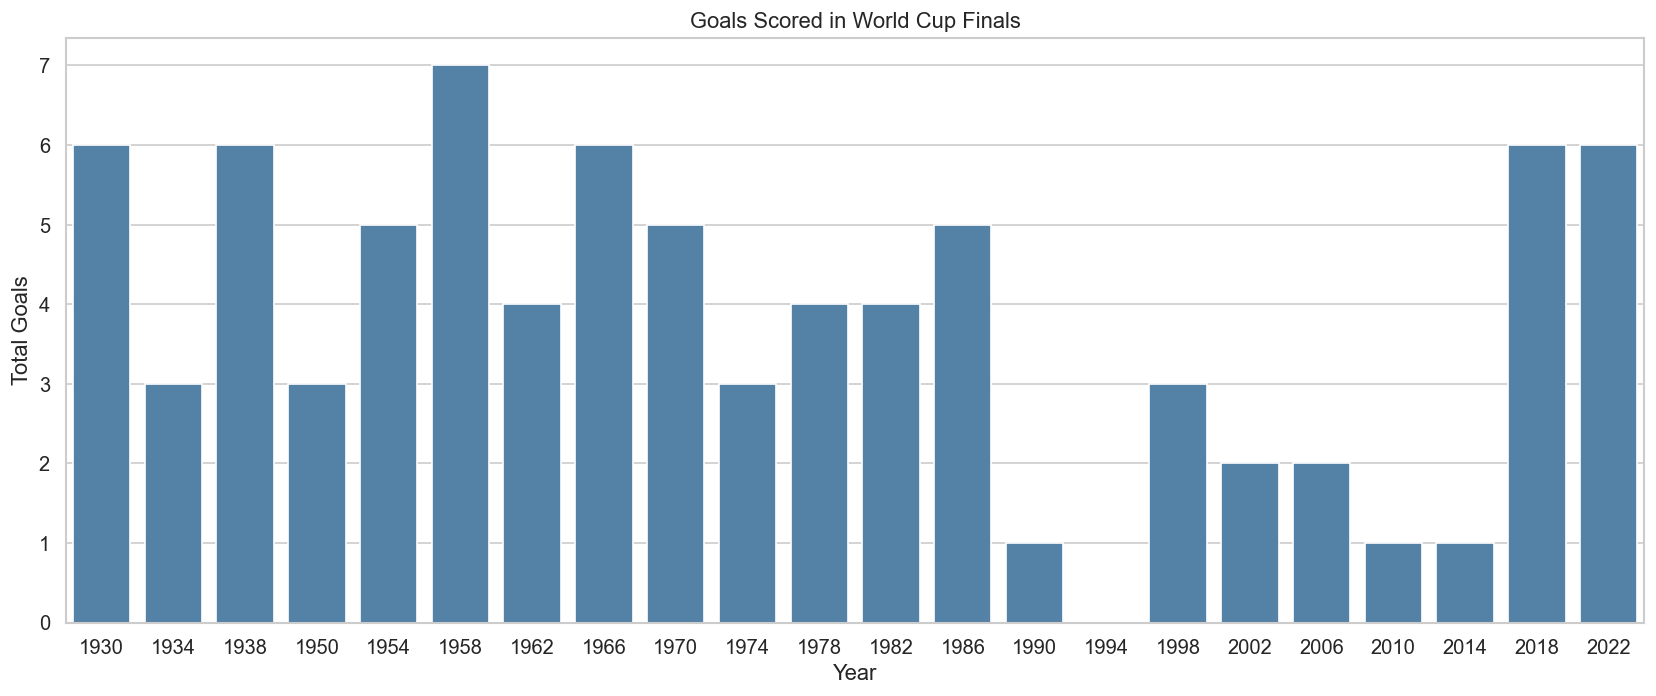

In [69]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=highest_scoring_finals,
    x="year",
    y="total_final_goals",
    color="steelblue"
)

plt.title("Goals Scored in World Cup Finals")

plt.xlabel("Year")

plt.ylabel("Total Goals")

plt.tight_layout()

plt.show()

# Historical Insight 8

## Evolution of Top Scorer Goals

The number of goals scored by the tournament's top scorer reflects changes in offensive performance, tournament format, and the number of matches played.

This visualization illustrates how the Golden Boot winner's goal tally evolved across different World Cup editions.

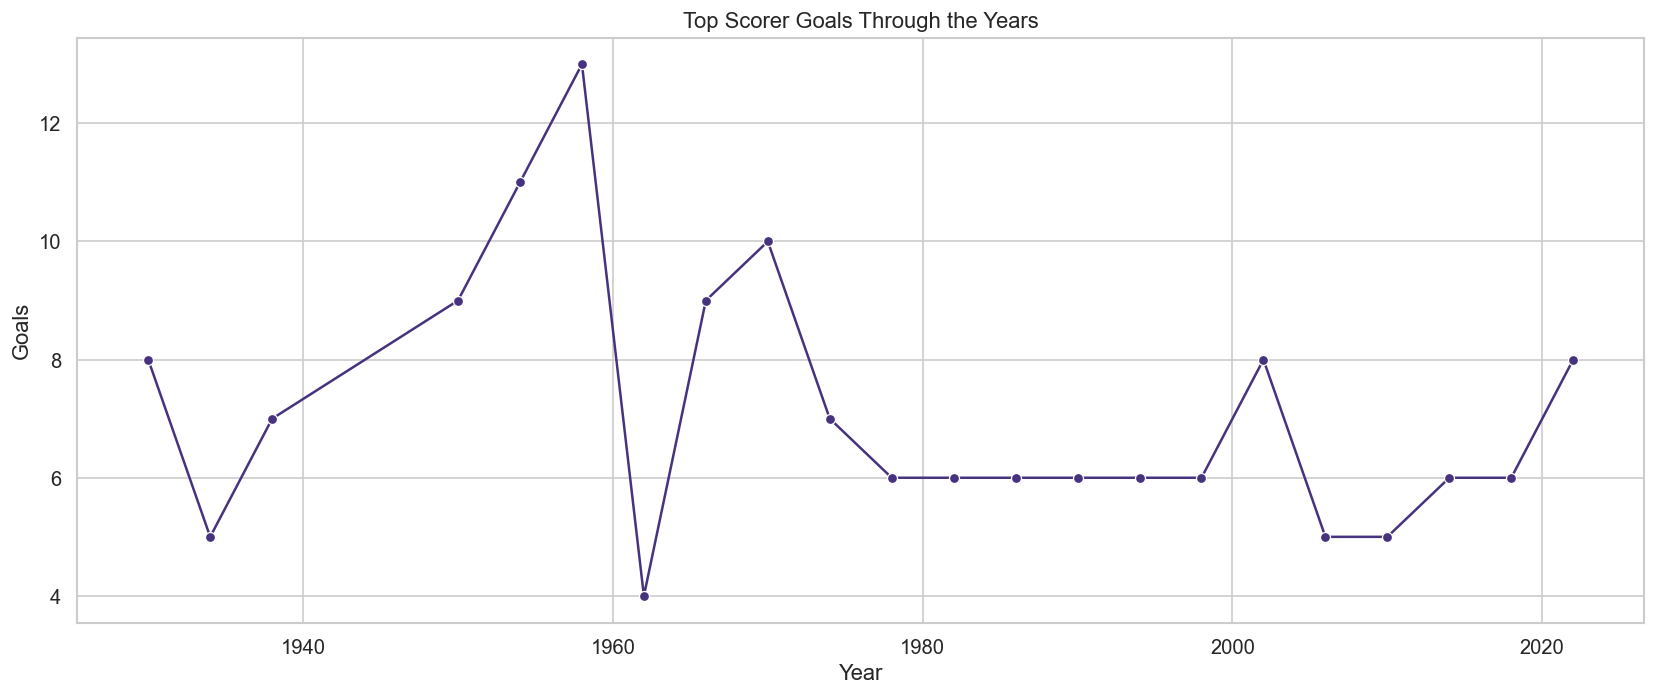

In [70]:
# ===========================================
# Top scorer goals through time
# ===========================================

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x="year",
    y="top_scorer_goals",
    marker="o"
)

plt.title("Top Scorer Goals Through the Years")

plt.xlabel("Year")

plt.ylabel("Goals")

plt.tight_layout()

plt.show()

In [71]:
# ===========================================
# Host nation performance
# ===========================================

df["host_won"] = (
    df["host_country"]
    == df["winner"]
)

In [72]:
host_results = (
    df["host_won"]
      .value_counts()
      .rename(
          {
              True: "Host Won",
              False: "Host Did Not Win"
          }
      )
)

host_results

host_won
Host Did Not Win    16
Host Won             6
Name: count, dtype: int64

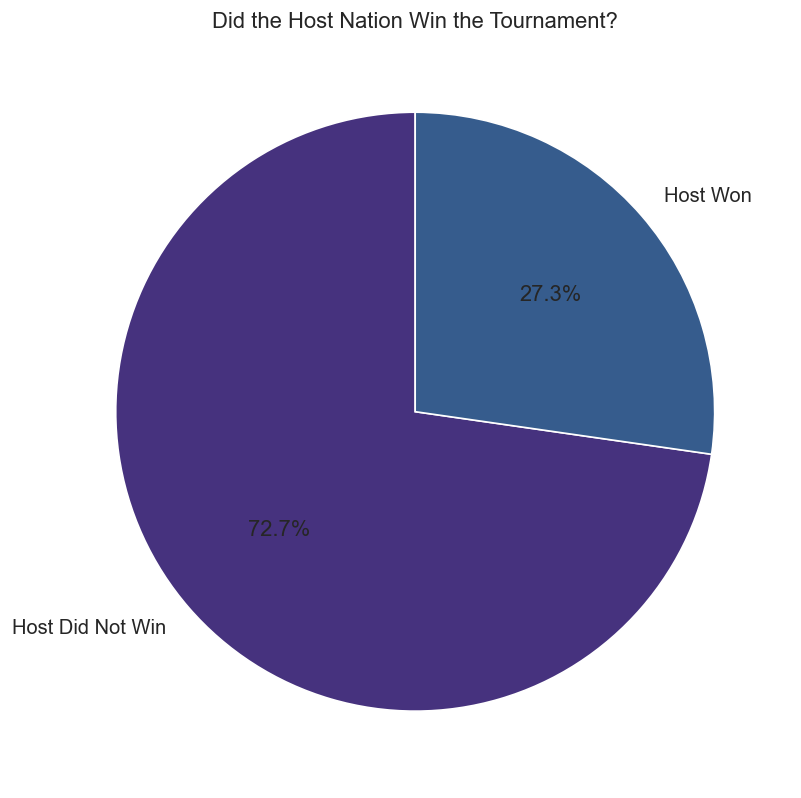

In [73]:
plt.figure(figsize=(7,7))

plt.pie(
    host_results,
    labels=host_results.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Did the Host Nation Win the Tournament?")

plt.tight_layout()

plt.show()

# Historical Insight 10

## Stadiums Hosting the World Cup Final

World Cup finals have been played in some of the world's most iconic stadiums.

This analysis compares the attendance recorded in finals held at different venues.

In [74]:
# ===========================================
# Stadium attendance
# ===========================================

stadium_attendance = (
    df[
        [
            "stadium",
            "attendance"
        ]
    ]
    .sort_values(
        "attendance",
        ascending=False
    )
)

stadium_attendance.head(10)

,stadium,attendance
3,Maracanã,173850
12,Estadio Azteca,114600
8,Estadio Azteca,107412
7,Wembley Stadium,96924
14,Rose Bowl,94194
11,Santiago Bernabéu Stadium,90000
21,Lusail Stadium,88966
18,Soccer City,84490
15,Stade de France,80000
9,Olympiastadion,78200


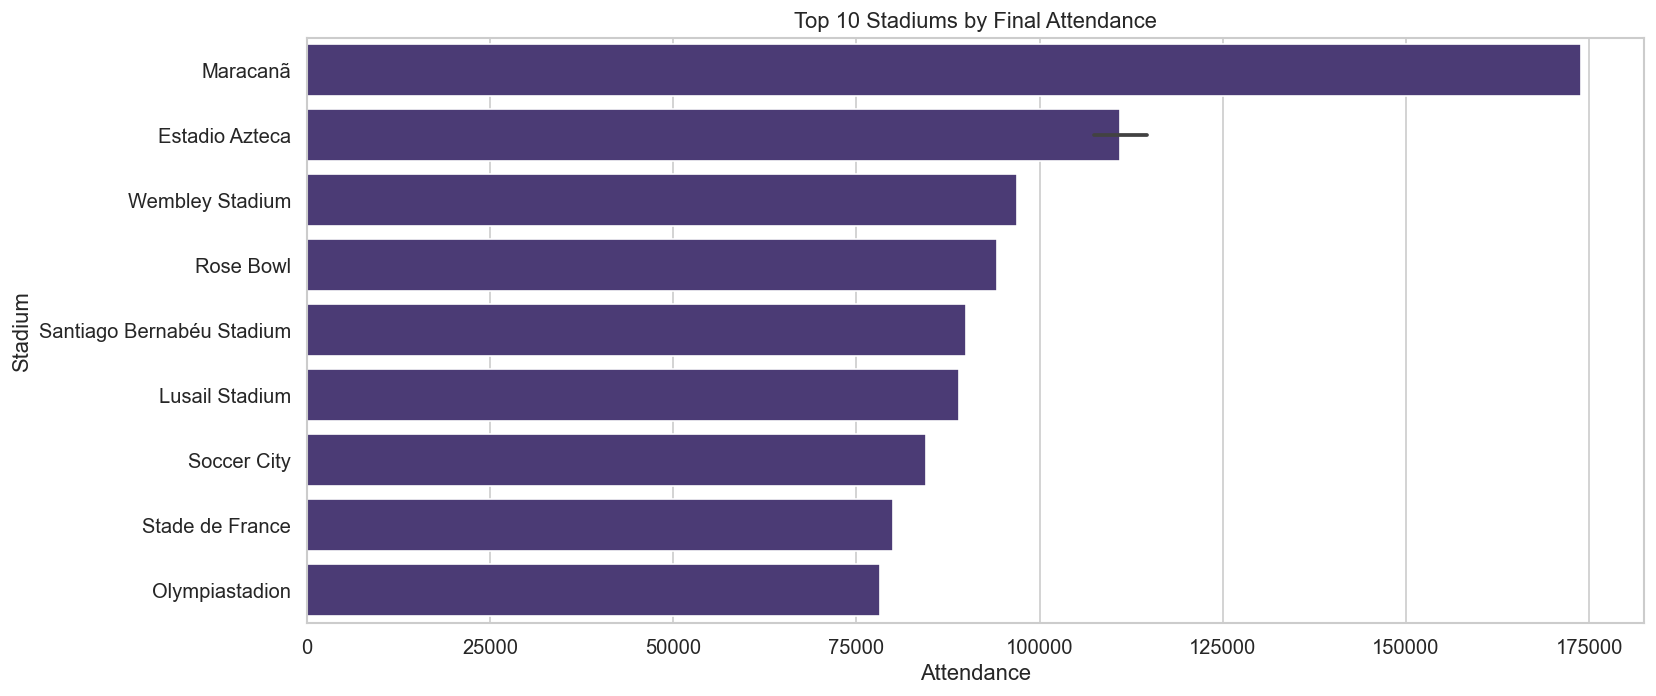

In [75]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=stadium_attendance.head(10),
    x="attendance",
    y="stadium"
)

plt.title("Top 10 Stadiums by Final Attendance")

plt.xlabel("Attendance")

plt.ylabel("Stadium")

plt.tight_layout()

plt.show()

# Historical Insight 11

## Evolution of Official Match Balls

The official match ball has become one of the most recognizable symbols of every FIFA World Cup.

This timeline presents the evolution of official match balls across tournament editions.

In [76]:
# ===========================================
# Official match balls
# ===========================================

official_balls = df[
    [
        "year",
        "official_ball"
    ]
]

official_balls

,year,official_ball
0,1930,T-Model
1,1934,Federale 102
2,1938,Allen
3,1950,Super Duplo T
4,1954,Swiss World Champion
5,1958,Top Star
6,1962,Crack
7,1966,Challenge 4-Star
8,1970,Telstar
9,1974,Telstar Durlast


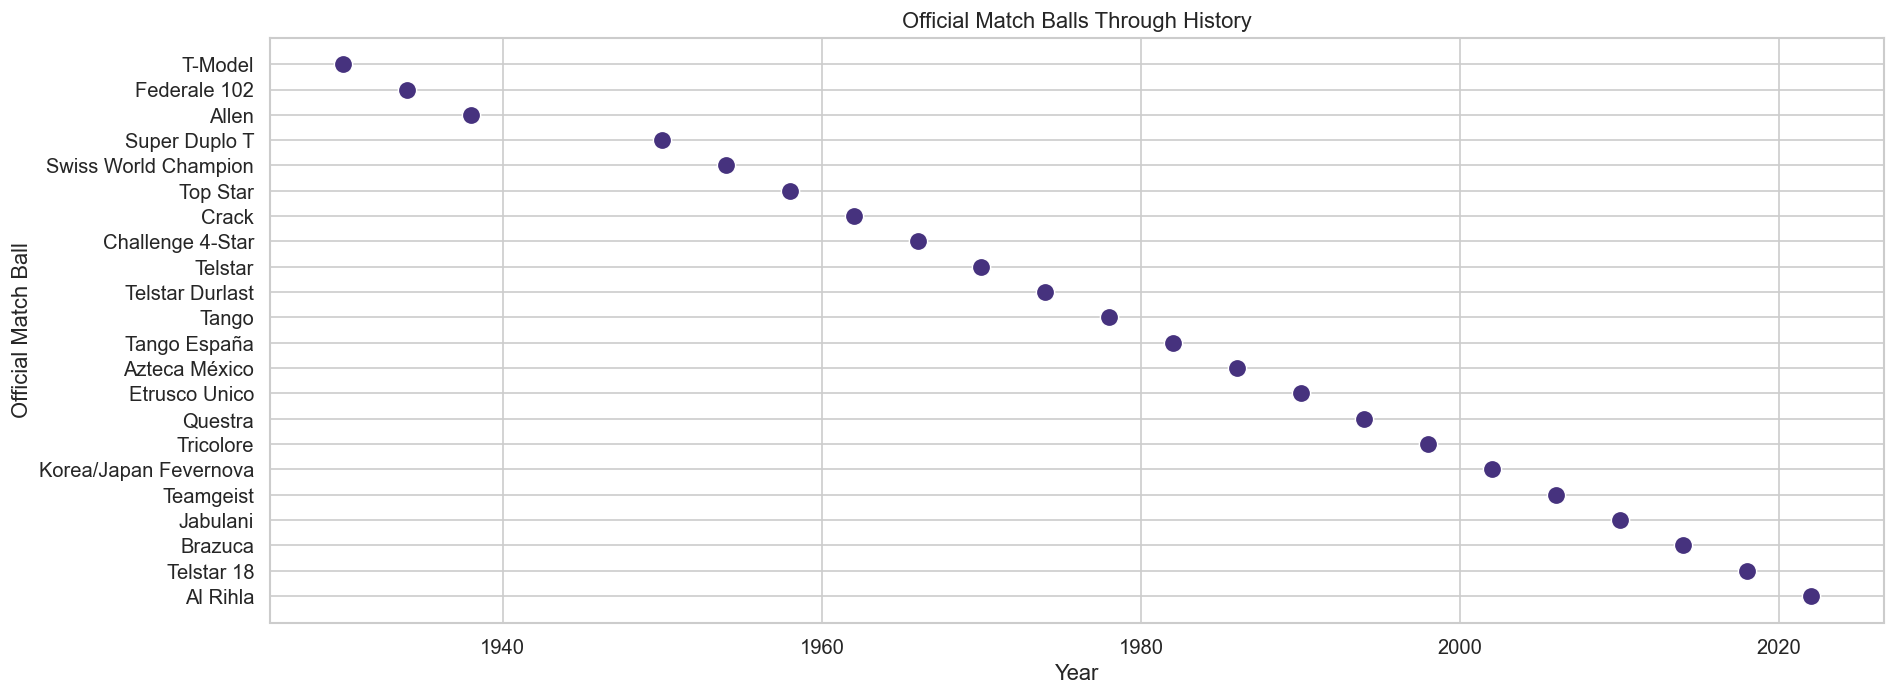

In [77]:
plt.figure(figsize=(16,6))

sns.scatterplot(
    data=official_balls,
    x="year",
    y="official_ball",
    s=120
)

plt.title("Official Match Balls Through History")

plt.xlabel("Year")

plt.ylabel("Official Match Ball")

plt.tight_layout()

plt.show()

# Historical Insight 12

## Evolution of FIFA World Cup Mascots

Since their introduction, World Cup mascots have become part of the tournament's identity.

This timeline illustrates the evolution of official mascots over time.

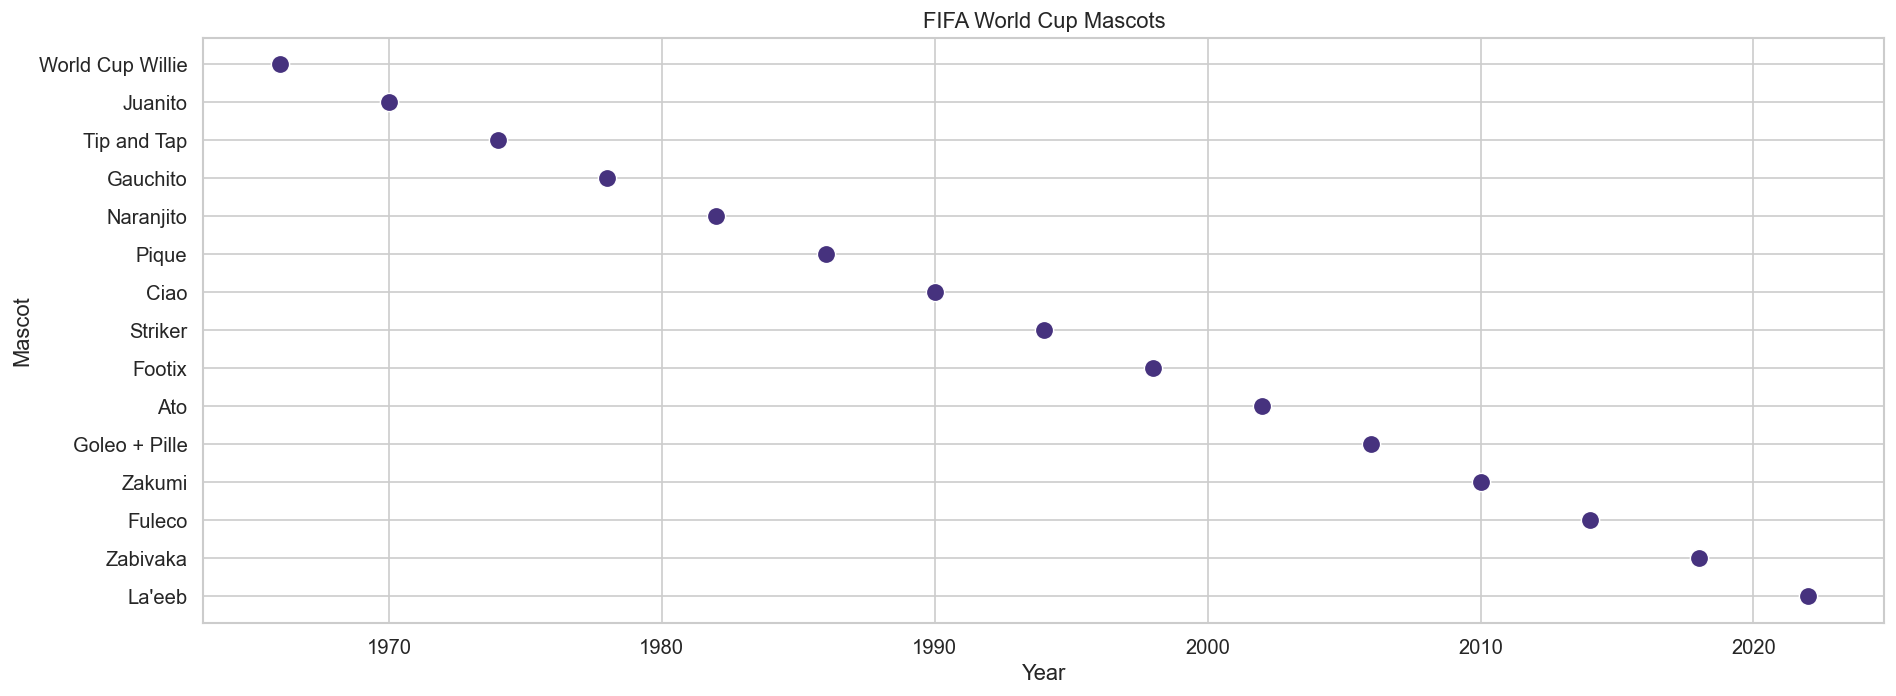

In [78]:
# ===========================================
# Mascots timeline
# ===========================================

plt.figure(figsize=(16,6))

sns.scatterplot(
    data=df,
    x="year",
    y="mascot",
    s=120
)

plt.title("FIFA World Cup Mascots")

plt.xlabel("Year")

plt.ylabel("Mascot")

plt.tight_layout()

plt.show()

# Historical Insight 13

## Countries with the Most World Cup Final Appearances

Winning the World Cup is the ultimate achievement.

However, consistently reaching the final also reflects long-term competitive excellence.

This analysis counts both championships and runner-up finishes to determine the countries with the most final appearances.

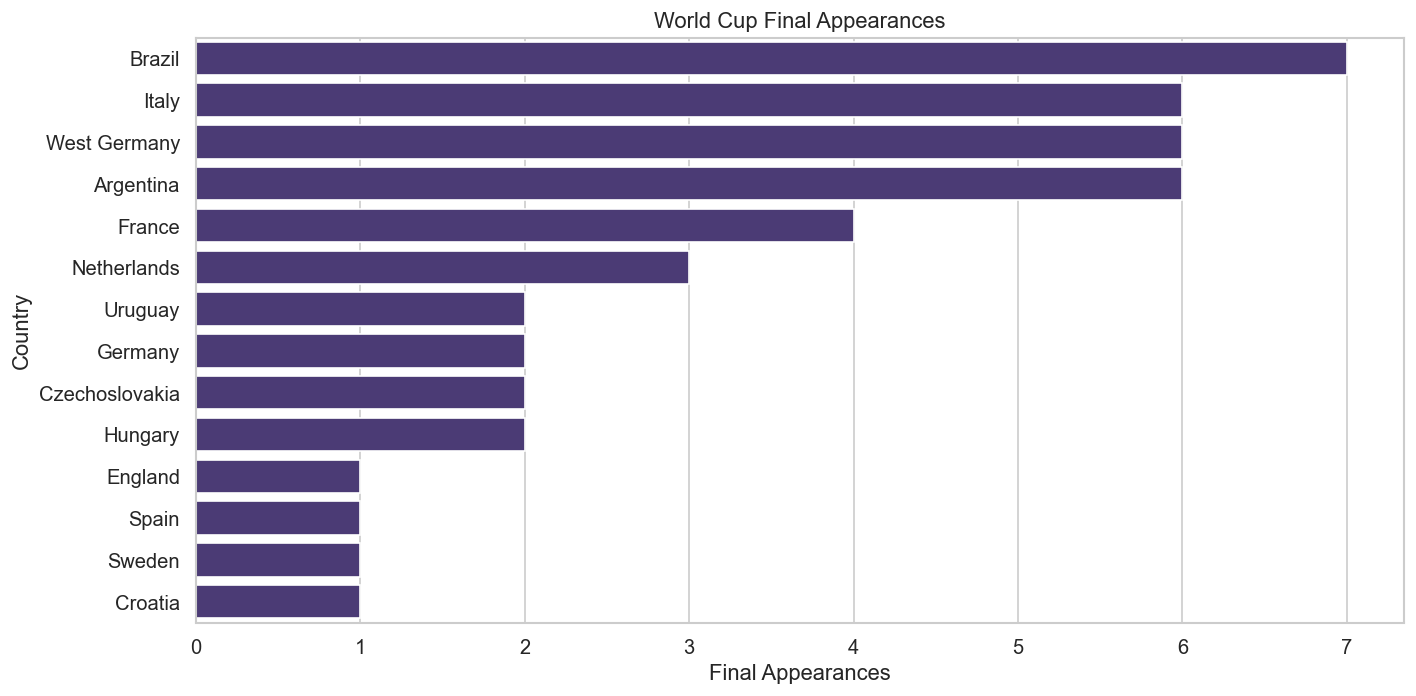

In [79]:
# ===========================================
# Final appearances
# ===========================================

finalists = pd.concat([
    df["winner"],
    df["runner_up"]
])

final_appearances = (
    finalists
    .value_counts()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=final_appearances.values,
    y=final_appearances.index
)

plt.title("World Cup Final Appearances")

plt.xlabel("Final Appearances")

plt.ylabel("Country")

plt.tight_layout()

plt.show()

# Historical Insight 14

## Continental Dominance by Decade

Rather than analyzing individual tournaments, grouping World Cups by decade provides a broader historical perspective.

This analysis highlights which continent dominated each era of the competition.

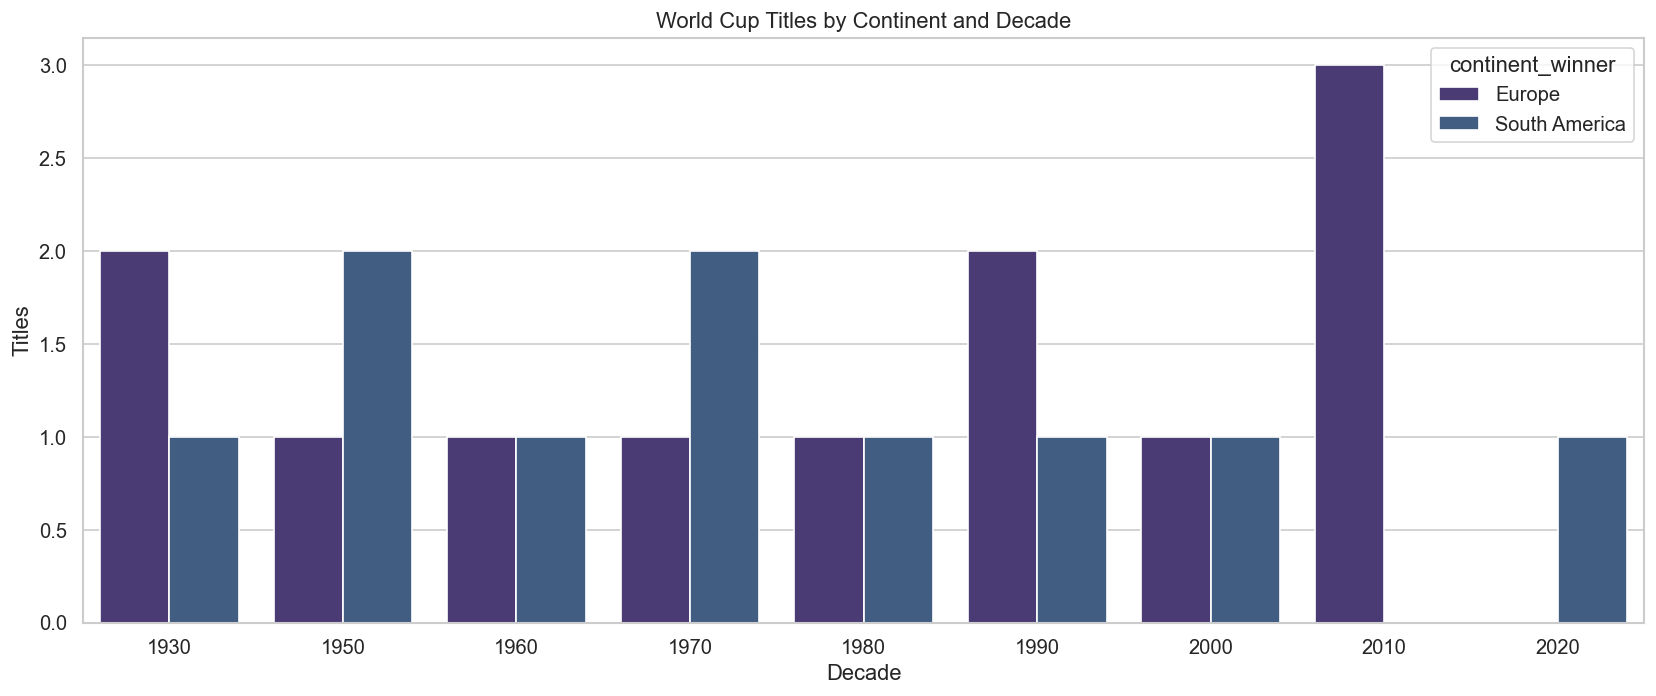

In [80]:
# ===========================================
# Continental dominance by decade
# ===========================================

df["decade"] = (df["year"] // 10) * 10

continent_by_decade = (
    df.groupby(
        [
            "decade",
            "continent_winner"
        ]
    )
    .size()
    .reset_index(name="titles")
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=continent_by_decade,
    x="decade",
    y="titles",
    hue="continent_winner"
)

plt.title("World Cup Titles by Continent and Decade")

plt.xlabel("Decade")

plt.ylabel("Titles")

plt.tight_layout()

plt.show()

# Historical Insight 15

## Timeline of FIFA World Cup Champions

A chronological timeline provides a clear historical overview of every FIFA World Cup champion.

This visualization summarizes more than ninety years of football history in a single figure.

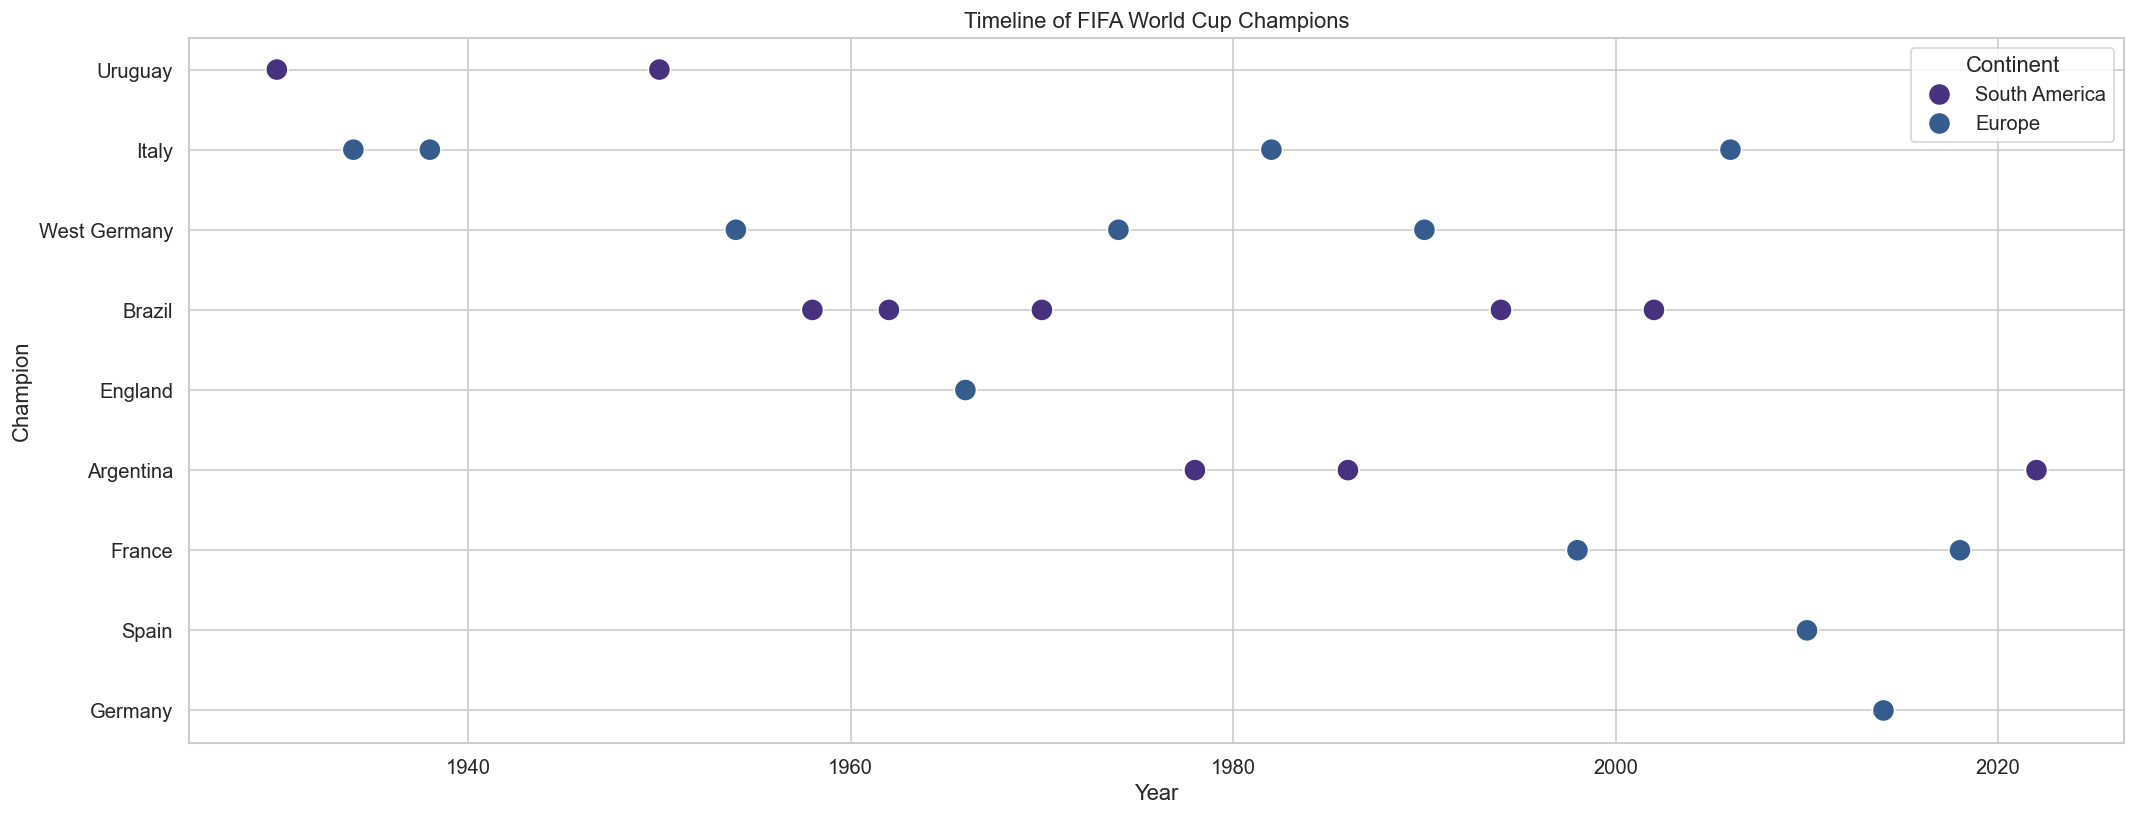

In [81]:
# ===========================================
# Champions timeline
# ===========================================

plt.figure(figsize=(18,7))

sns.scatterplot(
    data=df,
    x="year",
    y="winner",
    hue="continent_winner",
    s=180
)

plt.title("Timeline of FIFA World Cup Champions")

plt.xlabel("Year")

plt.ylabel("Champion")

plt.legend(title="Continent")

plt.tight_layout()

plt.show()